=== Loading and Processing Datasets ===
Processing 'Expert demonstrations': 100 episodes found.


Processing Expert demonstrations: 100%|██████████| 100/100 [00:00<00:00, 4378.10it/s]

  -> Kept 100 valid episodes.

=== Fz STATISTICAL METRICS (CALIBRATED) ===
------------------------------------------------------------
Metrics for: Expert demonstrations
  (Window: Button Click -> End of Episode)
  Fz Min : -3.1207
  Fz Max : 7.5297
  Fz Mean: 0.1009
  Fz Std : 0.8841
------------------------------------------------------------


=== Plotting Results ===
  [Positive Fz in Calibration Window] Episode 30: Max Fz in window is 2.0489
  [Positive Fz in Calibration Window] Episode 32: Max Fz in window is 1.4299
  [Positive Fz in Calibration Window] Episode 33: Max Fz in window is 1.3161


3


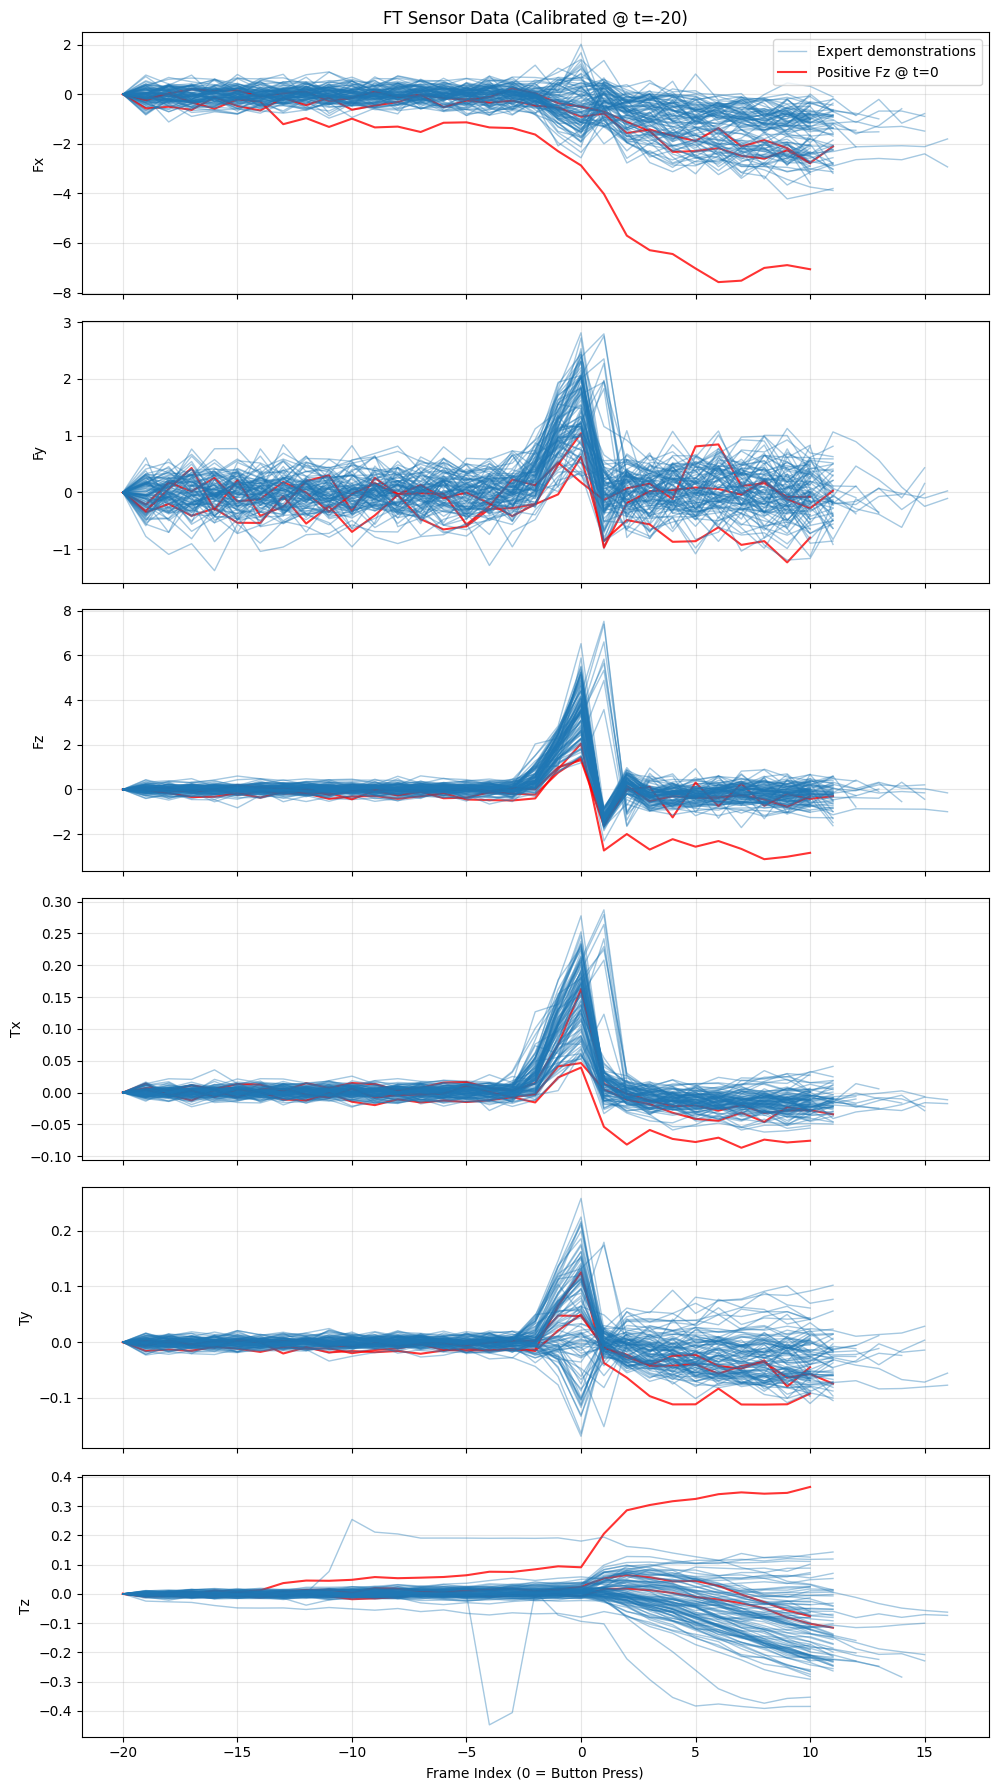

In [22]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from lerobot.datasets.lerobot_dataset import LeRobotDataset
import pickle
from tqdm import tqdm
# --- Configuration ---
# Add as many datasets as you want here.
# Key = Label for plots/metrics, Value = Path to dataset
datasets = {}
datasets["Expert demonstrations"] = "/home/rtalwar/robot-imitation-glue/datasets/expert/red_round_button_small_train"
# datasets["scratch"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_ft/red_round_button_small_audio_scratch"
# datasets["button"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_ft/red_round_button_small_audio_button"
# datasets["pretrained"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_ft/red_round_button_small_audio_pretrained"

# Keys in the dataset
BTN_STATE_KEY = "btn_state" 
FT_KEY = "ft"

calibration_timesteps=20

def extract_sync_and_calibrate_episodes(dataset, label_name):
    """
    Extracts FT data, filters empty episodes, syncs based on falling edge 
    of button state, and calibrates (tares) data based on t = -20.
    """
    processed_episodes = []
    
    num_episodes = dataset.meta.total_episodes
    print(f"Processing '{label_name}': {num_episodes} episodes found.")

    # PROJECT & FORMAT THE DATASET: 
    # This instructs the underlying Arrow table to only load the columns we need 
    # and directly formats the output as fast contiguous NumPy arrays.
    projected_ds = dataset.hf_dataset.with_format(
        type="numpy", 
        columns=[FT_KEY, BTN_STATE_KEY]
    )

    for episode_idx in tqdm(range(num_episodes), desc=f"Processing {label_name}"):
        # Get indices for this episode
        episode_indices = dataset.meta.episodes[episode_idx]
        start_idx = int(episode_indices["dataset_from_index"])
        end_idx = int(episode_indices["dataset_to_index"])

        # --- Vectorized Slice (No loop needed) ---
        slice_data = projected_ds[start_idx:end_idx]
        
        # slice_data is a dict containing only the two requested columns as NumPy arrays
        ft_data = slice_data[FT_KEY]             # Shape: (T, 6)
        btn_data = slice_data[BTN_STATE_KEY].flatten() # Shape: (T,)

        # --- Synchronization Logic ---
        diffs = np.diff(btn_data)
        falling_edges = np.where(diffs == -1)[0]

        if len(falling_edges) == 0:
            continue
        
        # Sync on the FIRST falling edge (index of '1' before '0')
        sync_idx = falling_edges[0] + 1
        
        # --- Calibration Logic ---
        calib_idx = sync_idx - calibration_timesteps
        if calib_idx < 0:
            calib_idx = 0 
        
        bias_vector = ft_data[calib_idx]            # Shape (6,)
        ft_data_calibrated = ft_data - bias_vector  # Broadcast subtraction
        
        # Create relative time axis
        episode_len = len(btn_data)
        time_axis = np.arange(episode_len) - sync_idx
        
        processed_episodes.append({
            "time": time_axis,
            "ft": ft_data_calibrated,
            "episode_id": episode_idx
        })

    print(f"  -> Kept {len(processed_episodes)} valid episodes.")
    return processed_episodes

def get_fz_metrics(episode_list):
    """
    Calculates Min, Max, Mean, Std for Fz (index 2) 
    from time >= 0 (button click) to end of episode.
    """
    all_fz_values = []
    
    for ep in episode_list:
        mask = ep["time"] >= -calibration_timesteps
        fz_segment = ep["ft"][mask, 2] 
        all_fz_values.append(fz_segment)
    return all_fz_values

def print_fz_metrics(episode_list, dataset_name):
    """
    Calculates Min, Max, Mean, Std for Fz (index 2) 
    from time >= 0 (button click) to end of episode.
    """
    all_fz_values = get_fz_metrics(episode_list)

    flat_fz = np.concatenate(all_fz_values)
    
    print("-" * 60)
    print(f"Metrics for: {dataset_name}")
    print(f"  (Window: Button Click -> End of Episode)")
    print(f"  Fz Min : {np.min(flat_fz):.4f}")
    print(f"  Fz Max : {np.max(flat_fz):.4f}")
    print(f"  Fz Mean: {np.mean(flat_fz):.4f}")
    print(f"  Fz Std : {np.std(flat_fz):.4f}")
    print("-" * 60)

# --- Main Execution Loop ---
all_processed_data = {}

# 1. Load and Process all datasets
print("=== Loading and Processing Datasets ===")
for label, path in datasets.items():
    ds = LeRobotDataset(repo_id="", root=path)
    all_processed_data[label] = extract_sync_and_calibrate_episodes(ds, label)

# 2. Calculate Metrics
print("\n=== Fz STATISTICAL METRICS (CALIBRATED) ===")
for label, data in all_processed_data.items():
    print_fz_metrics(data, label)
print("\n")

# 3. Plotting
print("=== Plotting Results ===")
fig, axes = plt.subplots(6, 1, figsize=(10, 18), sharex=True)
ft_labels = ["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]

# Get default color cycle from matplotlib
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

def plot_dataset_group(axes, episode_list, color, label_prefix):
    first_normal = True
    first_red = True
    teller = 0
    for ep in episode_list:
        t = ep["time"]
        ft = ep["ft"] # shape (T, 6)
        
        # Find index where time is 0 (sync_idx)
        # idx_0 = np.where(t == 0)[0]
        # is_red = False
        
        # if len(idx_0) > 0:
        #     fz_at_sync = ft[idx_0[0], 2]  # Fz is index 2 (the 3rd element)
        #     if fz_at_sync > 1:
        #         is_red = True
        #         print(f"  [Positive Fz @ t=0] Episode {ep['episode_id']}: Fz is {fz_at_sync:.4f}")
        #         teller+=1
        idx_0 = np.where(t == 0)[0]

        is_red = False
        if np.max(ft[idx_0[0]-calibration_timesteps:,2]) < np.abs(np.min(ft[idx_0[0]-calibration_timesteps:,2])):
            is_red = True
            print(f"  [Positive Fz in Calibration Window] Episode {ep['episode_id']}: Max Fz in window is {np.max(ft[idx_0[0]-calibration_timesteps:,2]):.4f}")
            teller+=1
        # Set visualization attributes
        line_color = "red" if is_red else color
        alpha = 0.8 if is_red else 0.4
        linewidth = 1.5 if is_red else 1.0
        
        for dim in range(6):
            # Create a clean dual-legend system (one for normal runs, one for red runs)
            if is_red:
                lbl = "Positive Fz @ t=0" if (first_red and dim == 0) else None
                if dim == 0:
                    first_red = False
            else:
                lbl = label_prefix if (first_normal and dim == 0) else None
                if dim == 0:
                    first_normal = False
                    
            axes[dim].plot(t[idx_0[0]-calibration_timesteps:], ft[idx_0[0]-calibration_timesteps:, dim], color=line_color, alpha=alpha, linewidth=linewidth, label=lbl)
    print(teller)
# Loop over processed data and plot each
for i, (label, data) in enumerate(all_processed_data.items()):
    color = color_cycle[i % len(color_cycle)]
    plot_dataset_group(axes, data, color, label)

# Formatting
for i in range(6):
    axes[i].set_ylabel(ft_labels[i])
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(loc="upper right")
        axes[i].set_title("FT Sensor Data (Calibrated @ t=-20)")

axes[-1].set_xlabel("Frame Index (0 = Button Press)")
plt.tight_layout()
plt.show()

In [13]:
peaks = []
for dem in all_processed_data["Expert demonstrations"]:
    t = dem["time"]
    fz = dem["ft"][:, 2]
    
    # Find the index where relative time is 0
    idx_0 = np.where(t == 0)[0]
    if len(idx_0) > 0:
        if np.max(fz[idx_0[0] - calibration_timesteps:]) > np.abs(np.min(fz[idx_0[0] - calibration_timesteps:])):
            continue  # Skip this "red demonstration" and proceed to the next one
            
    peaks.append(np.min(fz))

In [14]:
print(np.mean(peaks))
print(np.median(peaks))

-2.0958252
-1.6291351


In [15]:
# import torch
# import matplotlib.pyplot as plt
# import numpy as np
# from lerobot.datasets.lerobot_dataset import LeRobotDataset
# import pickle
# from tqdm import tqdm
# # --- Configuration ---
# # Add as many datasets as you want here.
# # Key = Label for plots/metrics, Value = Path to dataset
# datasets = {}
# # datasets["Expert demonstrations"] = "/home/rtalwar/robot-imitation-glue/datasets/delta_xyz_final_rgb"
# # datasets["Vision Only"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_rgb_n_action_1_fixed_button"
# # datasets["vision + button_signal (num_inference_steps = 40)"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_rgb_instrumentation_n_action_1_40_eps"
# # datasets["Vision + button_signal (num_inference_steps = 10)"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_rgb_instrumentation_n_action_1_40_eps_10_inf"
# # datasets["Vision + button_signal + audio MIT AST embeddings frozen"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_final_rgb_audio_mit_frozen_instrumentation_n_action_1_40_eps_fixed_button"
# # datasets["Vision + button_signal + audio MIT AST embeddings unfrozen"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_final_rgb_audio_mit_unfrozen_instrumentation_n_action_1_40_eps_fixed_button"
# # datasets["Vision + audio MIT AST embeddings frozen"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_final_rgb_audio_mit_frozen_n_action_1_40_eps_fixed_button"
# # datasets["Vision + audio MIT AST embeddings unfrozen"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_final_rgb_audio_mit_unfrozen_n_action_1_40_eps_fixed_button"
# # datasets["Vision + button_signal model but button_signal replaced with the output of the audio AST classifier"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_final_rgb_fake_BUTTON_signal_n_action_1_40_eps_fixed_button"
# # datasets["Vision + audio BUTTON AST classifier frozen"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_final_rgb_audio_BUTTON_frozen_n_action_1_40_eps_fixed_button"
# # datasets["Vision + audio BUTTON AST classifier unfrozen"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_final_rgb_audio_BUTTON_unfrozen_n_action_1_40_eps_fixed_button"
# # datasets["Vision + audio BUTTON AST embedding frozen"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_final_rgb_audio_BUTTON_frozen_embedding_n_action_1_40_eps_fixed_button"
# # datasets["Vision + audio BUTTON AST embedding unfrozen"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_final_rgb_audio_BUTTON_unfrozen_embedding_n_action_1_40_eps"
# datasets["Expert demonstrations"] = "/home/rtalwar/robot-imitation-glue/datasets/red_round_button_big_train"
# # datasets["scratch"] = "/home/rtalwar/robot-imitation-glue/datasets/eval/red_round_button_small_audio_scratch_2"
# # datasets["button"] = "/home/rtalwar/robot-imitation-glue/datasets/eval/red_round_button_small_audio_button_2"
# # datasets["pretrained"] = "/home/rtalwar/robot-imitation-glue/datasets/eval/red_round_button_small_audio_pretrained_2"

# # Keys in the dataset
# BTN_STATE_KEY = "btn_state" 
# FT_KEY = "ft"

# def extract_sync_and_calibrate_episodes(dataset, label_name):
#     """
#     Extracts FT data, filters empty episodes, syncs based on falling edge 
#     of button state, and calibrates (tares) data based on t = -10.
#     """
#     processed_episodes = []
    
#     num_episodes = dataset.meta.total_episodes
#     print(f"Processing '{label_name}': {num_episodes} episodes found.")

#     # PROJECT & FORMAT THE DATASET: 
#     # This instructs the underlying Arrow table to only load the columns we need 
#     # and directly formats the output as fast contiguous NumPy arrays.
#     projected_ds = dataset.hf_dataset.with_format(
#         type="numpy", 
#         columns=[FT_KEY, BTN_STATE_KEY]
#     )

#     for episode_idx in tqdm(range(num_episodes), desc=f"Processing {label_name}"):
#         # Get indices for this episode
#         episode_indices = dataset.meta.episodes[episode_idx]
#         start_idx = int(episode_indices["dataset_from_index"])
#         end_idx = int(episode_indices["dataset_to_index"])

#         # --- Vectorized Slice (No loop needed) ---
#         slice_data = projected_ds[start_idx:end_idx]
        
#         # slice_data is a dict containing only the two requested columns as NumPy arrays
#         ft_data = slice_data[FT_KEY]             # Shape: (T, 6)
#         btn_data = slice_data[BTN_STATE_KEY].flatten() # Shape: (T,)

#         # --- Synchronization Logic ---
#         diffs = np.diff(btn_data)
#         falling_edges = np.where(diffs == -1)[0]

#         if len(falling_edges) == 0:
#             continue
        
#         # Sync on the FIRST falling edge (index of '1' before '0')
#         sync_idx = falling_edges[0] + 1
        
#         # --- Calibration Logic ---
#         calib_idx = sync_idx - 20
#         if calib_idx < 0:
#             calib_idx = 0 
        
#         bias_vector = ft_data[calib_idx]            # Shape (6,)
#         ft_data_calibrated = ft_data - bias_vector  # Broadcast subtraction
        
#         # Create relative time axis
#         episode_len = len(btn_data)
#         time_axis = np.arange(episode_len) - sync_idx
        
#         processed_episodes.append({
#             "time": time_axis,
#             "ft": ft_data_calibrated,
#             "episode_id": episode_idx
#         })

#     print(f"  -> Kept {len(processed_episodes)} valid episodes.")
#     return processed_episodes

# def get_fz_metrics(episode_list):
#     """
#     Calculates Min, Max, Mean, Std for Fz (index 2) 
#     from time >= 0 (button click) to end of episode.
#     """
#     all_fz_values = []
    
#     for ep in episode_list:
#         mask = ep["time"] >= 0
#         fz_segment = ep["ft"][mask, 2] 
#         all_fz_values.append(fz_segment)
#     return all_fz_values

# def print_fz_metrics(episode_list, dataset_name):
#     """
#     Calculates Min, Max, Mean, Std for Fz (index 2) 
#     from time >= 0 (button click) to end of episode.
#     """
#     all_fz_values = get_fz_metrics(episode_list)

#     flat_fz = np.concatenate(all_fz_values)
    
#     print("-" * 60)
#     print(f"Metrics for: {dataset_name}")
#     print(f"  (Window: Button Click -> End of Episode)")
#     print(f"  Fz Min : {np.min(flat_fz):.4f}")
#     print(f"  Fz Max : {np.max(flat_fz):.4f}")
#     print(f"  Fz Mean: {np.mean(flat_fz):.4f}")
#     print(f"  Fz Std : {np.std(flat_fz):.4f}")
#     print("-" * 60)

# # --- Main Execution Loop ---
# all_processed_data = {}

# # 1. Load and Process all datasets
# print("=== Loading and Processing Datasets ===")
# for label, path in datasets.items():
#     ds = LeRobotDataset(repo_id="", root=path)
#     all_processed_data[label] = extract_sync_and_calibrate_episodes(ds, label)
# # save dataset as pickle file
# # pickle.dump(all_processed_data, open("/home/rtalwar/robot-imitation-glue/datasets/all_processed_data.pkl", "wb"))
# # all_processed_data = pickle.load(open("/home/rtalwar/robot-imitation-glue/datasets/all_processed_data.pkl", "rb"))

# # 2. Calculate Metrics
# print("\n=== Fz STATISTICAL METRICS (CALIBRATED) ===")
# for label, data in all_processed_data.items():
#     print_fz_metrics(data, label)
# print("\n")

# # 3. Plotting
# print("=== Plotting Results ===")
# fig, axes = plt.subplots(6, 1, figsize=(10, 18), sharex=True)
# ft_labels = ["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]

# # Get default color cycle from matplotlib (Blue, Orange, Green, Red, Purple, Brown...)
# color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# def plot_dataset_group(axes, episode_list, color, label_prefix):
#     first = True
#     for ep in episode_list:
#         t = ep["time"]
#         ft = ep["ft"] # shape (T, 6)
        
#         for dim in range(6):
#             lbl = label_prefix if (first and dim == 0) else None
#             axes[dim].plot(t, ft[:, dim], color=color, alpha=0.5, linewidth=1.2, label=lbl)
#         first = False

# # Loop over processed data and plot each
# for i, (label, data) in enumerate(all_processed_data.items()):
#     # Pick a color from the cycle (modulo to wrap around if >10 datasets)
#     color = color_cycle[i % len(color_cycle)]
#     plot_dataset_group(axes, data, color, label)

# # Formatting
# for i in range(6):
#     axes[i].set_ylabel(ft_labels[i])
#     axes[i].grid(True, alpha=0.3)
#     if i == 0:
#         axes[i].legend(loc="upper right")
#         axes[i].set_title("FT Sensor Data (Calibrated @ t=-10)")

# axes[-1].set_xlabel("Frame Index (0 = Button Press)")
# plt.tight_layout()
# plt.show()

analyze specific dataset

In [16]:
# import torch
# import matplotlib.pyplot as plt
# import numpy as np
# from lerobot.datasets.lerobot_dataset import LeRobotDataset
# import pickle
# BTN_STATE_KEY = "btn_state" 
# FT_KEY = "ft"

# dataset = LeRobotDataset(repo_id="", root="/home/rtalwar/robot-imitation-glue/datasets/eval/red_round_button_small_audio_scratch_2")
# num_episodes = dataset.meta.total_episodes
# print(f"Processing dataset: {num_episodes} episodes found.")

# for episode_idx in range(num_episodes):
#     # Get indices for this episode
#     episode_indices = dataset.meta.episodes[episode_idx]
#     start_idx = episode_indices["dataset_from_index"]
#     end_idx = episode_indices["dataset_to_index"]

#     # --- Loop to collect frame data ---
#     btn_list = []
    
#     for idx in range(start_idx, end_idx):
#         frame = dataset[idx]
        
#         btn_val = frame[BTN_STATE_KEY]
#         if isinstance(btn_val, torch.Tensor):
#             btn_val = btn_val.cpu().numpy()
            
#         btn_list.append(btn_val)
#     btn_data = np.stack(btn_list).flatten() # (T,)

#     if 0 in btn_data:
#         print(f"Button press detected in this {episode_idx}.")
#     else:
#         print(f"No button press detected in this {episode_idx}.")

In [17]:
# forces = all_processed_data["scratch"][-1]["ft"][:,2]
# time = all_processed_data["scratch"][-1]["time"]
# #plot force and x axis is time
# plt.figure(figsize=(10,5))
# plt.plot(time, forces, label="Fz (Calibrated)", color='blue')
# plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
# plt.xlabel("Frame Index (0 = Button Press)")
# plt.ylabel("Fz Force (Calibrated)")
# plt.title("Fz Force over Time for 'scratch' Dataset")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

In [18]:
# import torch
# import matplotlib.pyplot as plt
# import numpy as np
# from lerobot.datasets.lerobot_dataset import LeRobotDataset
# import pickle
# BTN_STATE_KEY = "btn_state" 
# FT_KEY = "ft"

# dataset = LeRobotDataset(repo_id="", root="/home/rtalwar/robot-imitation-glue/datasets/eval/red_round_button_small_audio_scratch_2")
# num_episodes = dataset.meta.total_episodes
# print(f"Processing dataset: {num_episodes} episodes found.")

# for episode_idx in range(num_episodes-2, num_episodes):
#     # Get indices for this episode
#     episode_indices = dataset.meta.episodes[episode_idx]
#     start_idx = episode_indices["dataset_from_index"]
#     end_idx = episode_indices["dataset_to_index"]
#     print(f"Episode {episode_idx}: Frames {start_idx} to {end_idx}")
#     # --- Loop to collect frame data ---
#     btn_list = []
#     ft_list = []
    
#     for idx in range(start_idx, end_idx):
#         frame = dataset[idx]
        
#         btn_val = frame[BTN_STATE_KEY]
#         if isinstance(btn_val, torch.Tensor):
#             btn_val = btn_val.cpu().numpy()
            
#         btn_list.append(btn_val)
        
#         ft_val = frame[FT_KEY]
#         if isinstance(ft_val, torch.Tensor):
#             ft_val = ft_val.cpu().numpy()
            
#         ft_list.append(ft_val)
#     btn_data = np.stack(btn_list).flatten() # (T,)
#     ft_data = np.stack(ft_list) # (T, 6)

#     # --- Synchronization Logic ---
#     diffs = np.diff(btn_data)
#     falling_edges = np.where(diffs == -1)[0]

#     if len(falling_edges) == 0:
#         # print(f"  Episode {episode_idx}: No button press detected, skipping.")
#         continue
    
#     # Sync on the FIRST falling edge (index of '1' before '0')
#     sync_idx = falling_edges[0] + 1
    
#     # --- Calibration Logic ---
#     # Use data at sync_idx - 10 as zero-point
#     calib_idx = sync_idx - 10
    
#     # Ensure we have enough history to calibrate
#     if calib_idx < 0:
#         calib_idx = 0 
    
#     bias_vector = ft_data[calib_idx] # Shape (6,)
#     ft_data_calibrated = ft_data - bias_vector # Broadcast subtraction
    
#     # Create relative time axis
#     episode_len = len(btn_data)
#     time_axis = np.arange(episode_len) - sync_idx
# #plot ft_data[:,2] vs time (index) for the last episode
#     plt.figure(figsize=(10,5))
#     # plt.plot(ft_data[:,2], label="Fz (Raw)", color='blue')  

#     #now also plotting calibrated Fz
#     plt.plot(time_axis, ft_data_calibrated[:,2], label="Fz (Calibrated)", color='orange')  
#     plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
#     plt.xlabel("Frame Index (0 = Button Press)")
#     plt.ylabel("Fz Force")
#     plt.title(f"Fz Force over Time for Episode {episode_idx} (scratch dataset)")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

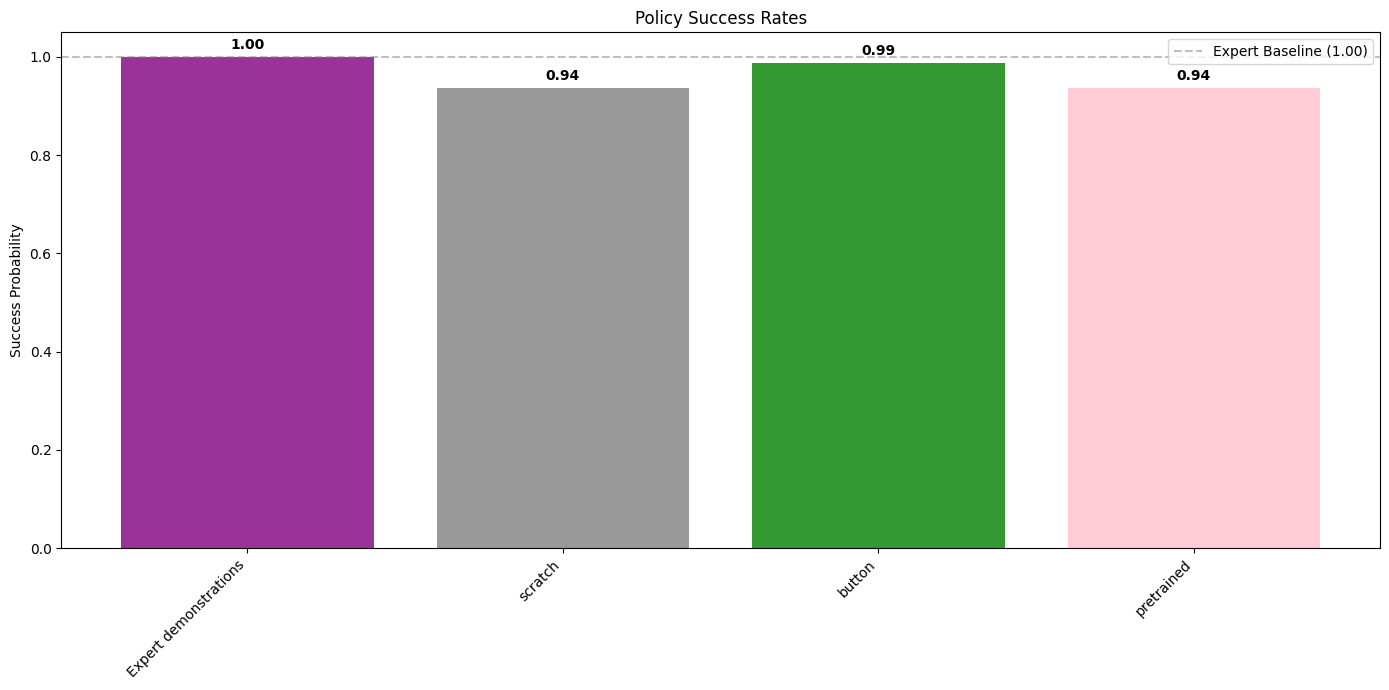

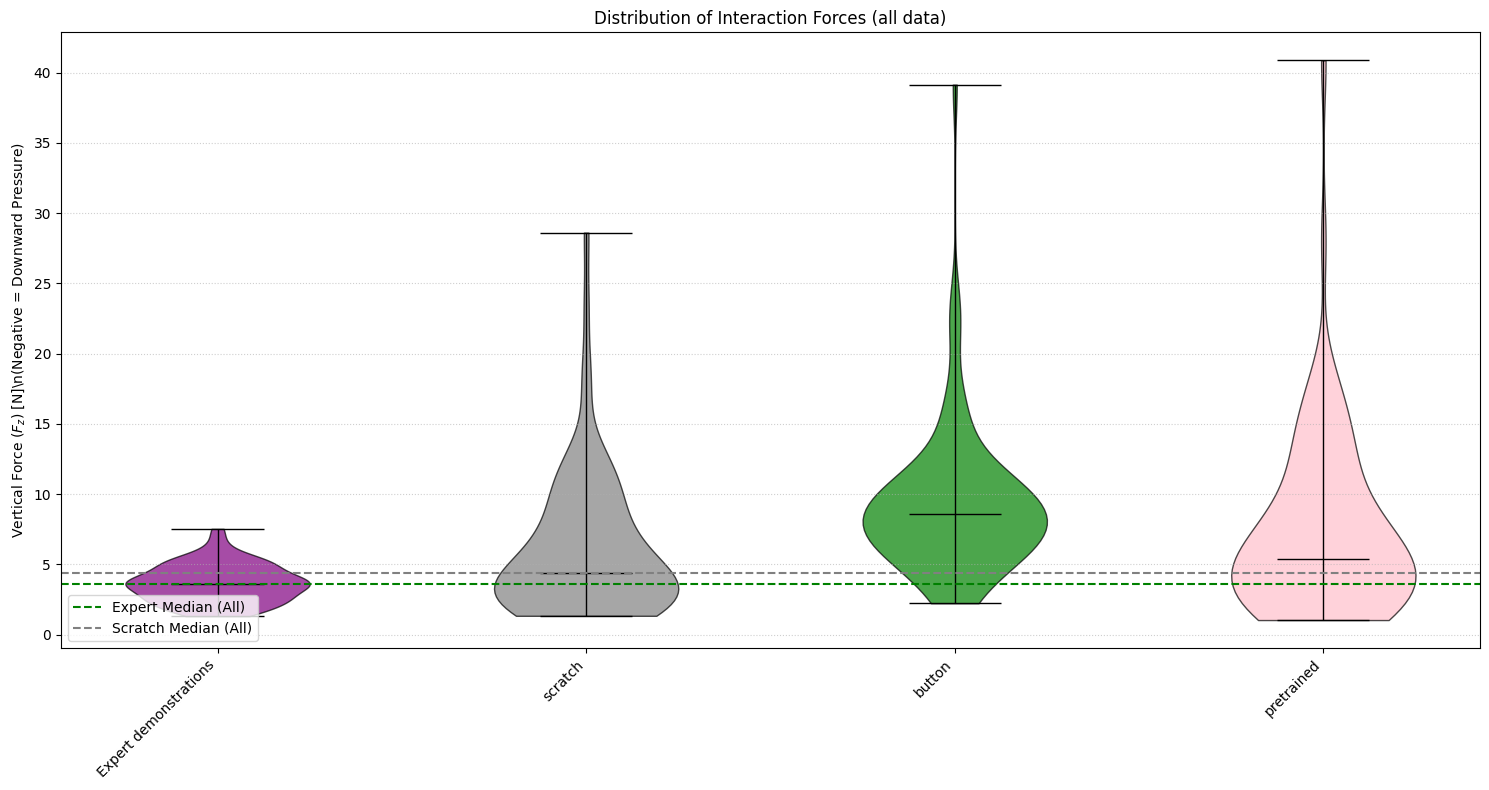

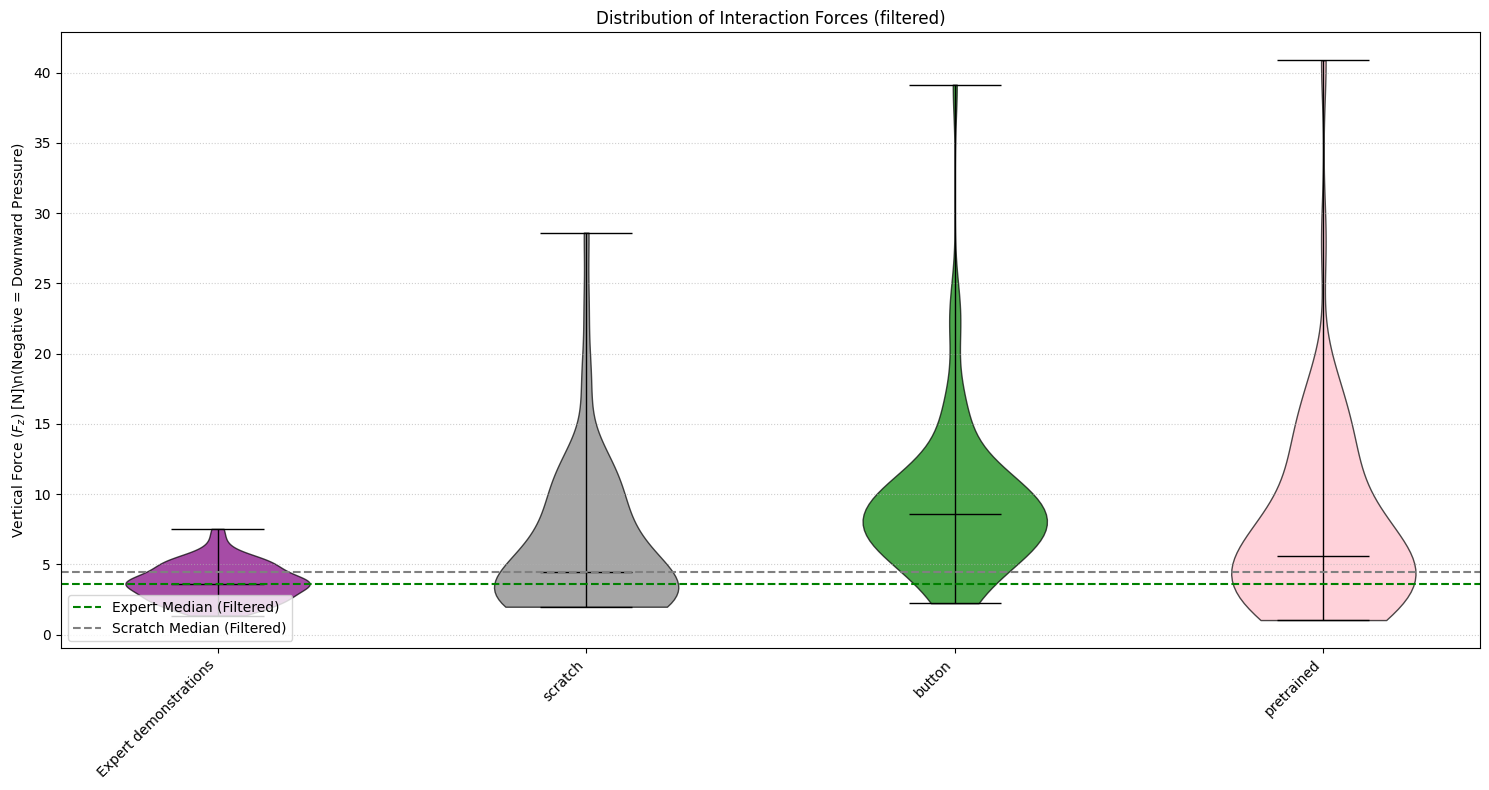

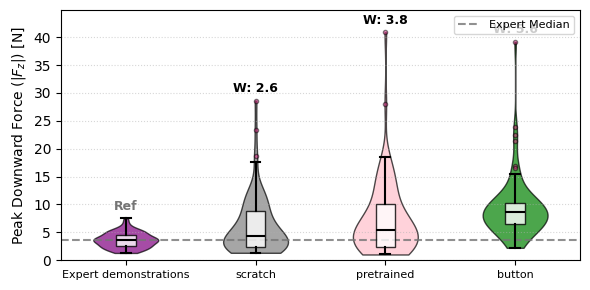

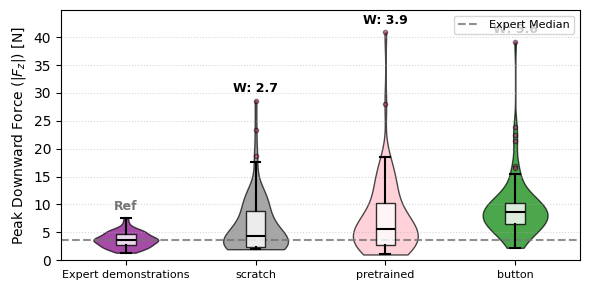

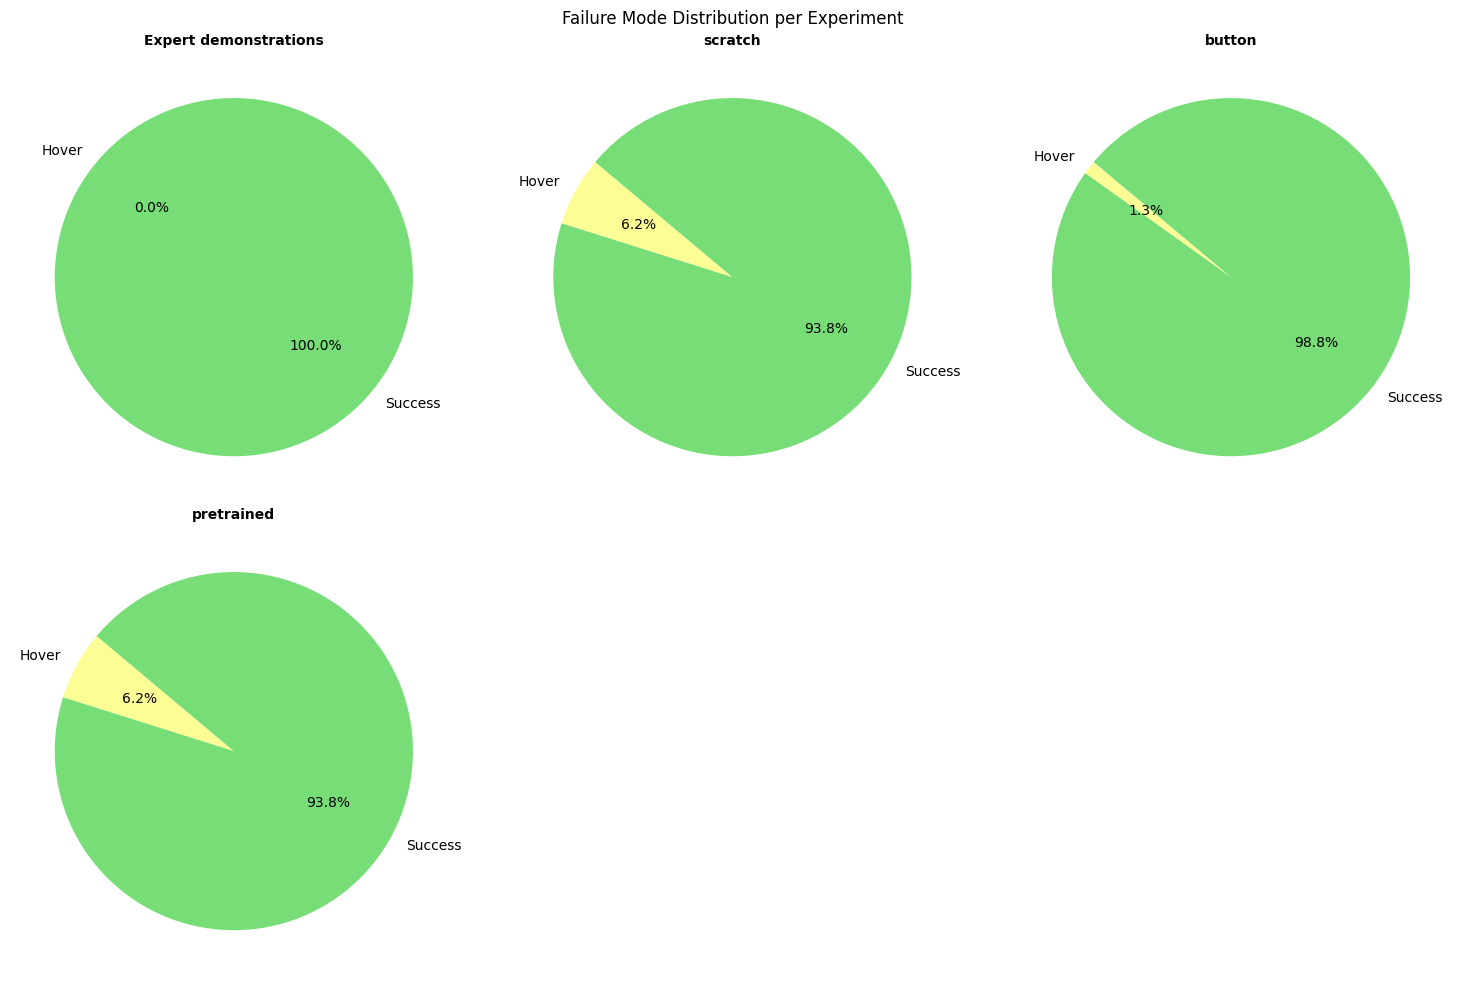

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import math

from scipy import stats

# ==========================================
# 1. DATA CONFIGURATION
# ==========================================
experiments = [
    {
        "name": "Expert demonstrations",
        "cats": {"Hover": 0,  "Success": 100},
        "too_hard_index":[],
        "sideways":[]
    },    
    {
        "name": "scratch",
        "cats": {"Hover": 5,  "Success": 75},
        "too_hard_index":[],
        "sideways":[]
    },
    {
        "name": "button",
        "cats": {"Hover": 1,  "Success": 79},
        "too_hard_index":[],
        "sideways":[]
    },
    {
        "name": "pretrained",
        "cats": {"Hover": 5,  "Success": 75},
        "too_hard_index":[],
        "sideways":[]
    },
]

# ==========================================
# 1b. CALCULATE METRICS DYNAMICALLY
# ==========================================
for exp in experiments:
    cats = exp["cats"]
    n = sum(cats.values())
    n_success = cats.get("Success", 0)
    n_hard = cats.get("Too Hard", 0)
    
    # Strict Metrics
    p_strict = n_success / n
    
    exp["p_strict"] = p_strict
    exp["total_n"] = n

names = [e["name"] for e in experiments]
colors = ["purple"]+['gray', 'green'] + ['pink']*2 + ['lightblue']*2 + ['gold'] + ['orange']*2 + ['red']*2

# ==========================================
# 2a. STRICT SUCCESS RATE BAR CHART
# ==========================================
success_rates = [e["p_strict"] for e in experiments]

plt.figure(figsize=(14, 7))
bars = plt.bar(names, success_rates, capsize=5, color=colors, alpha=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

base_expert = experiments[0]["p_strict"]
plt.axhline(y=base_expert, color='gray', linestyle='--', alpha=0.5, label=f"Expert Baseline ({base_expert:.2f})")

plt.ylabel("Success Probability")
plt.title("Policy Success Rates")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 3. PREPARE FORCE DATA (ALL + FILTERED)
# ==========================================
experiment_names = [experiment["name"] for experiment in experiments]
name = list(all_processed_data.keys())
# name.remove("vision + button_signal (num_inference_steps = 40)")
# 1. Get Raw Data
raw_data_list = [all_processed_data[n] for n in names]

# 2. Extract Raw Metrics (Arrays per episode)
fz_values_all_episodes = [get_fz_metrics(d) for d in raw_data_list]
time_values_all_episodes = [[ep["time"] for ep in exp] for exp in raw_data_list]
# 3. Get Episode IDs
experiment_episodes = []
for experiment_runs in raw_data_list:
    episode_indices = []
    for run in experiment_runs:
        episode_indices.append(run["episode_id"])
    experiment_episodes.append(episode_indices)

# 4. Helper to extract peaks (Minimum Fz)
def extract_peak_impacts(experiment_runs):
    peaks = []
    for run in experiment_runs:
        if run is not None and len(run) > 0:
            peaks.append(np.max(run)) 
    return peaks

# 5. DATA SET A: ALL DATA
fz_peaks_all = [extract_peak_impacts(runs) for runs in fz_values_all_episodes]

# 6. DATA SET B: FILTERED DATA (No "Too Hard")
fz_peaks_filtered = []
fz_peaks_filtered_sideways = []
for i, exp_name in enumerate(names):
    bad_indices = experiments[i].get("too_hard_index", [])
    bad_indices_sideways = experiments[i].get("sideways", [])
    current_force_runs = fz_values_all_episodes[i]
    current_ids = experiment_episodes[i]
    clean_runs = []
    clean_runs_sideways = []

    for force_run, ep_id in zip(current_force_runs, current_ids):
        if force_run is None or len(force_run) == 0:
            continue
        if ep_id in bad_indices:
            continue
        if np.max(force_run) < np.abs(np.min(force_run)):
            continue  # Skip this "red demonstration" and proceed to the next one

        clean_runs.append(force_run)
        if ep_id not in bad_indices_sideways:
            clean_runs_sideways.append(force_run)

    fz_peaks_filtered.append(extract_peak_impacts(clean_runs))
    fz_peaks_filtered_sideways.append(extract_peak_impacts(clean_runs_sideways))


def has_any_data(series_list):
    return any(len(v) > 0 for v in series_list)

# ==========================================
# 5.2. VIOLIN PLOT: ALL DATA
# ==========================================
if has_any_data(fz_peaks_all):
    fig, ax = plt.subplots(figsize=(15, 8))

    parts = ax.violinplot(fz_peaks_all, showmeans=False, showmedians=True, showextrema=True)

    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)

    for partname in ('cbars','cmins','cmaxes','cmedians'):
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(1)

    expert_median_all = np.median(fz_peaks_all[0]) if len(fz_peaks_all) > 0 and len(fz_peaks_all[0])>0 else np.nan
    scratch_median_all = np.median(fz_peaks_all[1]) if len(fz_peaks_all) > 1 and len(fz_peaks_all[1])>0 else np.nan
    if not np.isnan(expert_median_all):
        plt.axhline(y=expert_median_all, color='green', linestyle='--', linewidth=1.5, label="Expert Median (All)")
    if not np.isnan(scratch_median_all):
        plt.axhline(y=scratch_median_all, color='gray', linestyle='--', linewidth=1.5, label="Scratch Median (All)")

    plt.ylabel("Vertical Force ($F_z$) [N]\\n(Negative = Downward Pressure)")
    plt.title("Distribution of Interaction Forces (all data)")
    ax.set_xticks(np.arange(1, len(names) + 1))
    ax.set_xticklabels(names, rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')

    plt.tight_layout()
    plt.show()
else:
    print("No data available for all-data violin plot.")

# ==========================================
# 5.3. VIOLIN PLOT: FILTERED DATA
# ==========================================
if has_any_data(fz_peaks_filtered):
    fig, ax = plt.subplots(figsize=(15, 8))

    parts = ax.violinplot(fz_peaks_filtered, showmeans=False, showmedians=True, showextrema=True)

    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)

    for partname in ('cbars','cmins','cmaxes','cmedians'):
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(1)

    expert_median_filt = np.median(fz_peaks_filtered[0]) if len(fz_peaks_filtered) > 0 and len(fz_peaks_filtered[0])>0 else np.nan
    scratch_median_filt = np.median(fz_peaks_filtered[1]) if len(fz_peaks_filtered) > 1 and len(fz_peaks_filtered[1])>0 else np.nan
    if not np.isnan(expert_median_filt):
        plt.axhline(y=expert_median_filt, color='green', linestyle='--', linewidth=1.5, label="Expert Median (Filtered)")
    if not np.isnan(scratch_median_filt):
        plt.axhline(y=scratch_median_filt, color='gray', linestyle='--', linewidth=1.5, label="Scratch Median (Filtered)")

    plt.ylabel("Vertical Force ($F_z$) [N]\\n(Negative = Downward Pressure)")
    plt.title("Distribution of Interaction Forces (filtered)")
    ax.set_xticks(np.arange(1, len(names) + 1))
    ax.set_xticklabels(names, rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')

    plt.tight_layout()
    plt.show()
else:
    print("No data available for filtered-data violin plot.")

labels = names

data_source=[np.abs(d) for d in fz_peaks_all]

EXPERT_IDX = 0  
expert_data = data_source[EXPERT_IDX]
# Calculate metrics
wasserstein_distance =[] 
for i, data in enumerate(data_source):
    if len(data) == 0:
        wasserstein_distance.append(np.inf)
    else:
        wasserstein_distance.append(stats.wasserstein_distance(expert_data, data))


sort_tuples =[]
for i, dist in enumerate(wasserstein_distance):
    sort_tuples.append((dist, i))

sort_tuples.sort(key=lambda x: x[0]) 

sorted_dists = [t[0] for t in sort_tuples]
sorted_indices = [t[1] for t in sort_tuples]
sorted_data = [data_source[i] for i in sorted_indices]
sorted_labels_raw = [labels[i] for i in sorted_indices]

sorted_colors = [colors[i] for i in sorted_indices]

fig, ax = plt.subplots(figsize=(6, 3)) # Compact for 2-column paper

# 1. Draw Violins
parts = ax.violinplot(sorted_data, showmeans=False, showmedians=False, showextrema=False)
for pc, color in zip(parts['bodies'], sorted_colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 2. Draw Boxplots
bp = ax.boxplot(sorted_data, widths=0.15, patch_artist=True, showfliers=True, zorder=10)
for patch in bp['boxes']:
    patch.set_facecolor('white')
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')
for element in ['whiskers', 'caps', 'medians']:
    plt.setp(bp[element], color='black', linewidth=1.5)
plt.setp(bp['fliers'], marker='o', markerfacecolor='#e7298a', markeredgecolor='black', markersize=3, alpha=0.5)

# 3. Add Distance Annotations Above Violins
for i, dist in enumerate(sorted_dists):
    if sorted_indices[i] == EXPERT_IDX:
        txt = "Ref"
        font_weight = 'bold'
        color_txt = '#757575'
    else:
        txt = f"W: {dist:.1f}" # W for Wasserstein
        font_weight = 'bold'
        color_txt = 'black'
        
    y_max = np.max(sorted_data[i]) if len(sorted_data[i]) > 0 else 0
    # Add annotation slightly above the max point
    ax.text(i + 1, y_max + 1, txt, ha='center', va='bottom', 
            fontsize=9, fontweight=font_weight, color=color_txt)

# 4. Add Expert Baseline
expert_median = np.median(expert_data)
plt.axhline(y=expert_median, color='#757575', linestyle='--', linewidth=1.5, alpha=0.8, label="Expert Median")

# 5. Labels and Formatting
plt.ylabel("Peak Downward Force ($|F_z|$) [N]")

ax.set_xticks(np.arange(1, len(sorted_labels_raw) + 1))
ax.set_xticklabels(sorted_labels_raw, rotation=0, ha='center', fontsize=8)

# Adjust Y-limits
y_global_min = min([np.min(d) for d in sorted_data if len(d)>0])
y_global_max = max([np.max(d) for d in sorted_data if len(d)>0])
ax.set_ylim(bottom=max(0, y_global_min - 2), top=y_global_max + 4) # 0 is absolute floor

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()

plt.savefig("force_violins_filtered.pdf", dpi=300, bbox_inches='tight')
plt.show()

labels = names

data_source=[np.abs(d) for d in fz_peaks_filtered]

EXPERT_IDX = 0  
expert_data = data_source[EXPERT_IDX]
# Calculate metrics
wasserstein_distance =[] 
for i, data in enumerate(data_source):
    if len(data) == 0:
        wasserstein_distance.append(np.inf)
    else:
        wasserstein_distance.append(stats.wasserstein_distance(expert_data, data))


sort_tuples =[]
for i, dist in enumerate(wasserstein_distance):
    sort_tuples.append((dist, i))

sort_tuples.sort(key=lambda x: x[0]) 

sorted_dists = [t[0] for t in sort_tuples]
sorted_indices = [t[1] for t in sort_tuples]
sorted_data = [data_source[i] for i in sorted_indices]
sorted_labels_raw = [labels[i] for i in sorted_indices]

sorted_colors = [colors[i] for i in sorted_indices]

fig, ax = plt.subplots(figsize=(6, 3)) # Compact for 2-column paper

# 1. Draw Violins
parts = ax.violinplot(sorted_data, showmeans=False, showmedians=False, showextrema=False)
for pc, color in zip(parts['bodies'], sorted_colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 2. Draw Boxplots
bp = ax.boxplot(sorted_data, widths=0.15, patch_artist=True, showfliers=True, zorder=10)
for patch in bp['boxes']:
    patch.set_facecolor('white')
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')
for element in ['whiskers', 'caps', 'medians']:
    plt.setp(bp[element], color='black', linewidth=1.5)
plt.setp(bp['fliers'], marker='o', markerfacecolor='#e7298a', markeredgecolor='black', markersize=3, alpha=0.5)

# 3. Add Distance Annotations Above Violins
for i, dist in enumerate(sorted_dists):
    if sorted_indices[i] == EXPERT_IDX:
        txt = "Ref"
        font_weight = 'bold'
        color_txt = '#757575'
    else:
        txt = f"W: {dist:.1f}" # W for Wasserstein
        font_weight = 'bold'
        color_txt = 'black'
        
    y_max = np.max(sorted_data[i]) if len(sorted_data[i]) > 0 else 0
    # Add annotation slightly above the max point
    ax.text(i + 1, y_max + 1, txt, ha='center', va='bottom', 
            fontsize=9, fontweight=font_weight, color=color_txt)

# 4. Add Expert Baseline
expert_median = np.median(expert_data)
plt.axhline(y=expert_median, color='#757575', linestyle='--', linewidth=1.5, alpha=0.8, label="Expert Median")

# 5. Labels and Formatting
plt.ylabel("Peak Downward Force ($|F_z|$) [N]")

ax.set_xticks(np.arange(1, len(sorted_labels_raw) + 1))
ax.set_xticklabels(sorted_labels_raw, rotation=0, ha='center', fontsize=8)

# Adjust Y-limits
y_global_min = min([np.min(d) for d in sorted_data if len(d)>0])
y_global_max = max([np.max(d) for d in sorted_data if len(d)>0])
ax.set_ylim(bottom=max(0, y_global_min - 2), top=y_global_max + 4) # 0 is absolute floor

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()

plt.savefig("force_violins_filtered.pdf", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 6. PIE CHARTS
# ==========================================
num_exp = len(experiments)
cols = 3
rows = math.ceil(num_exp / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

category_colors = {
    "Success": "#77dd77", 
    "Hover": "#fdfd96",   
    "Too Hard": "#ff6961",
    "Sideways": "#84b6f4",  
    "Fake": "#cda4de"     
}

for i, exp in enumerate(experiments):
    ax = axes[i]
    labels = list(exp["cats"].keys())
    sizes = list(exp["cats"].values())
    
    # Map colors
    pie_colors = [category_colors.get(l.split(" ")[0], "gray") for l in labels]
    
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=pie_colors)
    ax.set_title(exp["name"], fontsize=10, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Failure Mode Distribution per Experiment", fontsize=12)
plt.tight_layout()
plt.show()


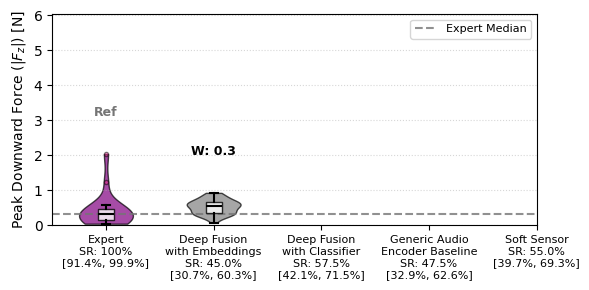

<Figure size 640x480 with 0 Axes>

In [14]:
from tkinter import font

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def remove_outliers_iqr(data, k=1.5):
    if len(data) == 0:
        return data
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return data[(data >= lower) & (data <= upper)]

# ==========================================
# 1. SETUP & CALCULATE ALL DISTANCES
# ==========================================
# Assuming `fz_peaks_filtered_sideways` and `names` are defined as before.
# We take the ABSOLUTE value so "harder press" goes UP on the Y-axis.
REMOVE_OUTLIERS = False  # Toggle this to False to keep outliers
data_source = [np.abs(d) for d in fz_peaks_filtered_sideways]

if REMOVE_OUTLIERS:
    data_source = [remove_outliers_iqr(d) for d in data_source]
labels = names
EXPERT_IDX = 0  

expert_data = data_source[EXPERT_IDX]

# Calculate metrics
wasserstein_distance =[] 
for i, data in enumerate(data_source):
    if len(data) == 0:
        wasserstein_distance.append(np.inf)
    else:
        wasserstein_distance.append(stats.wasserstein_distance(expert_data, data))

# ==========================================
# 2. FILTER & SORT THE DATA
# ==========================================
HIDE_LABELS =[
    "Vision Only",
    "Oracle (Vision + Button Sig)",
    "Vision + Button Sig + Generic AST (Frozen Embed)",
    "Vision + Button Sig + Generic AST (Unfrozen Embed)",
    "Generic AST (Unfrozen Embed)",
    "Button AST (Unfrozen Classif)",
    "Button AST (Unfrozen Embed)"
]

sort_tuples =[]
for i, dist in enumerate(wasserstein_distance):
    if labels[i] not in HIDE_LABELS:
        sort_tuples.append((dist, i))

sort_tuples.sort(key=lambda x: x[0]) 

sorted_dists = [t[0] for t in sort_tuples]
sorted_indices = [t[1] for t in sort_tuples]
sorted_data = [data_source[i] for i in sorted_indices]
sorted_labels_raw = [labels[i] for i in sorted_indices]

# Define custom short labels and Success Rates (SR) for the X-axis
short_labels_map = {
    "Expert Demonstrations": "Expert\nSR: 100%\n[91.4%, 99.9%]",
    "Button AST Embedding": "Deep Fusion\nwith Embeddings\nSR: 45.0%\n[30.7%, 60.3%]",
    "Button AST Classifier": "Deep Fusion\nwith Classifier\nSR: 57.5%\n[42.1%, 71.5%]",
    "Generic AST Embedding": "Generic Audio\nEncoder Baseline\nSR: 47.5%\n[32.9%, 62.6%]",
    "Pseudo-Instr(Signal Swap)": "Soft Sensor\nSR: 55.0%\n[39.7%, 69.3%]"
}
sorted_labels =[short_labels_map[i] for i in short_labels_map]

# Semantic Colors: Gray for Expert, Blue for Good, Red/Orange for Bad

sorted_colors = [colors[i] for i in sorted_indices]

# ==========================================
# 3. PLOTTING (Optimized for 1 Column)
# ==========================================
fig, ax = plt.subplots(figsize=(6, 3)) # Compact for 2-column paper

# 1. Draw Violins
parts = ax.violinplot(sorted_data, showmeans=False, showmedians=False, showextrema=False)
for pc, color in zip(parts['bodies'], sorted_colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 2. Draw Boxplots
bp = ax.boxplot(sorted_data, widths=0.15, patch_artist=True, showfliers=True, zorder=10)
for patch in bp['boxes']:
    patch.set_facecolor('white')
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')
for element in ['whiskers', 'caps', 'medians']:
    plt.setp(bp[element], color='black', linewidth=1.5)
plt.setp(bp['fliers'], marker='o', markerfacecolor='#e7298a', markeredgecolor='black', markersize=3, alpha=0.5)

# 3. Add Distance Annotations Above Violins
for i, dist in enumerate(sorted_dists):
    if sorted_indices[i] == EXPERT_IDX:
        txt = "Ref"
        font_weight = 'bold'
        color_txt = '#757575'
    else:
        txt = f"W: {dist:.1f}" # W for Wasserstein
        font_weight = 'bold'
        color_txt = 'black'
        
    y_max = np.max(sorted_data[i]) if len(sorted_data[i]) > 0 else 0
    # Add annotation slightly above the max point
    ax.text(i + 1, y_max + 1, txt, ha='center', va='bottom', 
            fontsize=9, fontweight=font_weight, color=color_txt)

# 4. Add Expert Baseline
expert_median = np.median(expert_data)
plt.axhline(y=expert_median, color='#757575', linestyle='--', linewidth=1.5, alpha=0.8, label="Expert Median")

# 5. Labels and Formatting
plt.ylabel("Peak Downward Force ($|F_z|$) [N]")
# Removed main title, we will rely on LaTeX caption

ax.set_xticks(np.arange(1, len(sorted_labels) + 1))
ax.set_xticklabels(sorted_labels, rotation=0, ha='center', fontsize=8)
# ax.set_xticklabels(["Expert","Button AST\nEmbedding","Button AST\nClassifier","Generic AST\nEmbedding","Pseudo-Instr\n(Signal Swap)"], ha='center',fontsize=8)

# Adjust Y-limits
y_global_min = min([np.min(d) for d in sorted_data if len(d)>0])
y_global_max = max([np.max(d) for d in sorted_data if len(d)>0])
ax.set_ylim(bottom=max(0, y_global_min - 2), top=y_global_max + 4) # 0 is absolute floor

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()

plt.show()
#save figure as pdf
plt.savefig("force_violins.pdf", dpi=300, bbox_inches='tight')

Total Comparisons: 66
Corrected Alpha (Bonferroni): 0.000758
------------------------------------------------------------
expert vs Vision Only : p=0.00000 (DIFFERENT)
expert vs Oracle (Vision  : p=0.05820 (Same)
expert vs Vision + Button : p=0.00000 (DIFFERENT)
expert vs Vision + Button : p=0.00000 (DIFFERENT)
expert vs Generic AST (Fr : p=0.00000 (DIFFERENT)
expert vs Generic AST (Un : p=0.00000 (DIFFERENT)
expert vs Pseudo-Instr (S : p=0.00000 (DIFFERENT)
expert vs Button AST (Fro : p=0.00001 (DIFFERENT)
expert vs Button AST (Unf : p=0.00000 (DIFFERENT)
expert vs Button AST (Fro : p=0.00197 (Same)
expert vs Button AST (Unf : p=0.00005 (DIFFERENT)
Vision Only vs Oracle (Vision  : p=0.00002 (DIFFERENT)
Vision Only vs Vision + Button : p=0.32595 (Same)
Vision Only vs Vision + Button : p=0.74010 (Same)
Vision Only vs Generic AST (Fr : p=0.61610 (Same)
Vision Only vs Generic AST (Un : p=0.55544 (Same)
Vision Only vs Pseudo-Instr (S : p=0.33995 (Same)
Vision Only vs Button AST (Fro : p=0.

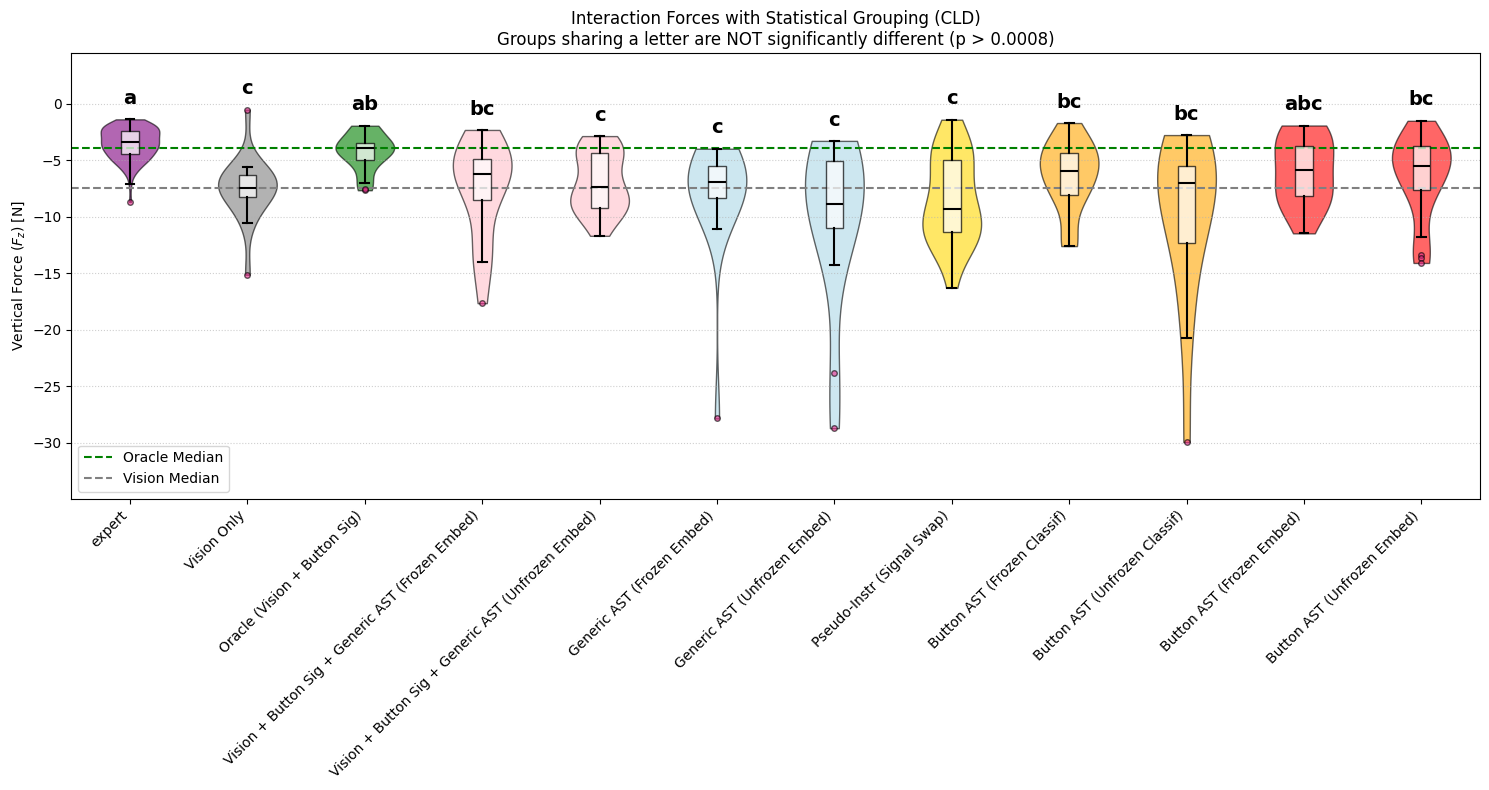

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import networkx as nx # We need this for the clique logic (CLD algorithm)

# ==========================================
# CONFIGURATION
# ==========================================
# Use your filtered force data
data_source = fz_peaks_filtered_sideways
labels = names

# TRI Paper choice: "Welch's t-test" (paramteric) OR "Mann-Whitney" (non-parametric)
# For N=40 force data, Mann-Whitney is safer, but TRI uses Welch.
TEST_TYPE = "Mann-Whitney" # Options: "Mann-Whitney", "Welch" , "ks"

# ==========================================
# 1. PAIRWISE TESTS & BONFERRONI
# ==========================================
n_groups = len(labels)
p_matrix = np.ones((n_groups, n_groups))

# Calculate number of comparisons: k * (k-1) / 2
num_comparisons = (n_groups * (n_groups - 1)) / 2

# Bonferroni corrected alpha (TRI uses global 95% confidence -> alpha 0.05)
alpha_global = 0.05
alpha_corrected = alpha_global / num_comparisons

print(f"Total Comparisons: {int(num_comparisons)}")
print(f"Corrected Alpha (Bonferroni): {alpha_corrected:.6f}")
print("-" * 60)

for i in range(n_groups):
    for j in range(i + 1, n_groups):
        data_a = data_source[i]
        data_b = data_source[j]
        
        if TEST_TYPE == "Mann-Whitney":
            stat, p = stats.mannwhitneyu(data_a, data_b, alternative='two-sided')
        elif TEST_TYPE == "Welch":
            stat, p = stats.ttest_ind(data_a, data_b, equal_var=False)
        elif TEST_TYPE == "ks":
            stat, p = stats.ks_2samp(data_a, data_b)
            
        p_matrix[i, j] = p
        p_matrix[j, i] = p
        
        # Debug print
        sig = "DIFFERENT" if p < alpha_corrected else "Same"
        print(f"{labels[i][:15]} vs {labels[j][:15]} : p={p:.5f} ({sig})")

# ==========================================
# 2. COMPACT LETTER DISPLAY (CLD) ALGO
# ==========================================
def get_cld_letters(p_mat, alpha_crit):
    """
    Generates the 'a', 'b', 'ab' labels based on a p-value matrix.
    Logic: 
    1. Create a graph where nodes are experiments.
    2. Draw an edge if p > alpha (i.e., NO significant difference).
    3. Find maximal cliques (groups that are all indistinguishable from each other).
    4. Assign a letter to each clique.
    """
    n = p_mat.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    
    # Add edges where there is NO significant difference
    for i in range(n):
        for j in range(i + 1, n):
            if p_mat[i, j] > alpha_crit:
                G.add_edge(i, j)
                
    # Find cliques (groups of items that are all similar to each other)
    # Finding maximal cliques is the standard way to assign CLD letters
    cliques = list(nx.find_cliques(G))
    
    # Sort cliques roughly by the mean value of their members (for "a" to be best)
    # We want "a" to represent the lowest force (closest to 0 or most negative depending on metric)
    # Here, assuming standard approach: "a" is usually the 'best' or 'control' group.
    
    # Assign letters
    import string
    letters = string.ascii_lowercase # 'a', 'b', 'c'...
    
    node_labels = {i: "" for i in range(n)}
    
    # We sort cliques so that the clique containing the "best" mean gets 'a'
    means = [np.mean(d) for d in data_source]
    # Sort cliques based on the average mean of nodes in the clique
    cliques.sort(key=lambda c: np.mean([means[node] for node in c]), reverse=True) # Reverse for "Smallest negative number (closest to 0) is 'a'"
    
    for idx, clique in enumerate(cliques):
        letter = letters[idx]
        for node in clique:
            # Append letter if not already present (to handle overlapping cliques)
            if letter not in node_labels[node]:
                node_labels[node] += letter
                
    # Sort letters inside string for consistency (e.g. "ba" -> "ab")
    final_labels = []
    for i in range(n):
        l = "".join(sorted(node_labels[i]))
        final_labels.append(l)
        
    return final_labels

cld_labels = get_cld_letters(p_matrix, alpha_corrected)

print("-" * 60)
print("CLD RESULTS (Sharing a letter = No Stat. Difference)")
for name, letter in zip(labels, cld_labels):
    print(f"{name:<40} | {letter}")

# ==========================================
# 3. PLOT WITH TRI-STYLE LABELS
# ==========================================
fig, ax = plt.subplots(figsize=(15, 8))

# Draw Violins & Boxplots (Reuse previous styling)
parts = ax.violinplot(data_source, showmeans=False, showmedians=False, showextrema=False)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.6)

bp = ax.boxplot(data_source, widths=0.15, patch_artist=True, showfliers=True, zorder=10)
for patch in bp['boxes']:
    patch.set_facecolor('white')
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
for element in ['whiskers', 'caps', 'medians']:
    plt.setp(bp[element], color='black', linewidth=1.5)
plt.setp(bp['fliers'], marker='o', markerfacecolor='#e7298a', markeredgecolor='black', markersize=4, alpha=0.6)

# --- ADD THE CLD LETTERS ---
# We place them slightly above the max value of each violin
for i, txt in enumerate(cld_labels):
    # Find max y for this group to position text
    y_max = np.max(data_source[i])
    ax.text(i + 1, y_max + 1, txt, ha='center', va='bottom', fontsize=14, fontweight='bold', color='black')

# Baselines
oracle_median = np.median(data_source[2]) # Index 1 is Oracle
plt.axhline(y=oracle_median, color='green', linestyle='--', linewidth=1.5, label="Oracle Median")

vision_median = np.median(data_source[1]) # Index 1 is Oracle
plt.axhline(y=vision_median, color='gray', linestyle='--', linewidth=1.5, label="Vision Median")

# Labels
plt.ylabel("Vertical Force ($F_z$) [N]")
plt.title(f"Interaction Forces with Statistical Grouping (CLD)\nGroups sharing a letter are NOT significantly different (p > {alpha_corrected:.4f})")
ax.set_xticks(np.arange(1, len(names) + 1))
ax.set_xticklabels(names, rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='lower left')

# Adjust Y-limit to make room for letters
y_global_min = min([np.min(d) for d in data_source])
y_global_max = max([np.max(d) for d in data_source])
ax.set_ylim(bottom=y_global_min - 5, top=y_global_max + 5)

plt.tight_layout()
plt.show()

KL divergence

In [5]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
# Use your filtered force data
data_source = fz_peaks_filtered_sideways
labels = names

EXPERT_IDX = 0  # Assuming the first item is the Expert demonstration

# ==========================================
# 1. CALCULATE DISTANCES TO EXPERT
# ==========================================
expert_data = data_source[EXPERT_IDX]
distances =[]

print("-" * 60)
print(f"{'Policy Name':<45} | {'Distance to Expert (Wasserstein) [N]':<15}")
print("-" * 60)

for i, data in enumerate(data_source):
    if i == EXPERT_IDX:
        dist = 0.0
    else:
        # Wasserstein distance handles empirical continuous samples perfectly
        dist = stats.wasserstein_distance(expert_data, data)
        
    distances.append(dist)
    print(f"{labels[i]:<45} | {dist:.3f} N")

print("-" * 60)

------------------------------------------------------------
Policy Name                                   | Distance to Expert (Wasserstein) [N]
------------------------------------------------------------
expert                                        | 0.000 N
Vision Only                                   | 4.073 N
Oracle (Vision + Button Sig)                  | 0.717 N
Vision + Button Sig + Generic AST (Frozen Embed) | 4.053 N
Vision + Button Sig + Generic AST (Unfrozen Embed) | 3.432 N
Generic AST (Frozen Embed)                    | 4.583 N
Generic AST (Unfrozen Embed)                  | 6.583 N
Pseudo-Instr (Signal Swap)                    | 4.990 N
Button AST (Frozen Classif)                   | 2.824 N
Button AST (Unfrozen Classif)                 | 6.440 N
Button AST (Frozen Embed)                     | 2.451 N
Button AST (Unfrozen Embed)                   | 2.952 N
------------------------------------------------------------


Policy Name                                | Wasserstein | Energy      | KL Diverg.  | JS Distance
--------------------------------------------------------------------------------------------------------------
expert                                     | 0.00 (REF)  | 0.00        | 0.00        | 0.00       
Vision Only                                | 4.07     N | 2.11       | 3.68        | 0.60    
Oracle (Vision + Button Sig)               | 0.72     N | 0.44       | 0.16        | 0.18    
Vision + Button Sig + Generic AST (Frozen Embed) | 4.05     N | 1.69       | 5.10        | 0.48    
Vision + Button Sig + Generic AST (Unfrozen Embed) | 3.43     N | 1.74       | 2.87        | 0.49    
Generic AST (Frozen Embed)                 | 4.58     N | 1.93       | 4.42        | 0.51    
Generic AST (Unfrozen Embed)               | 6.58     N | 2.23       | 8.05        | 0.57    
Pseudo-Instr (Signal Swap)                 | 4.99     N | 2.21       | 7.03        | 0.56    
Button AST (Frozen 

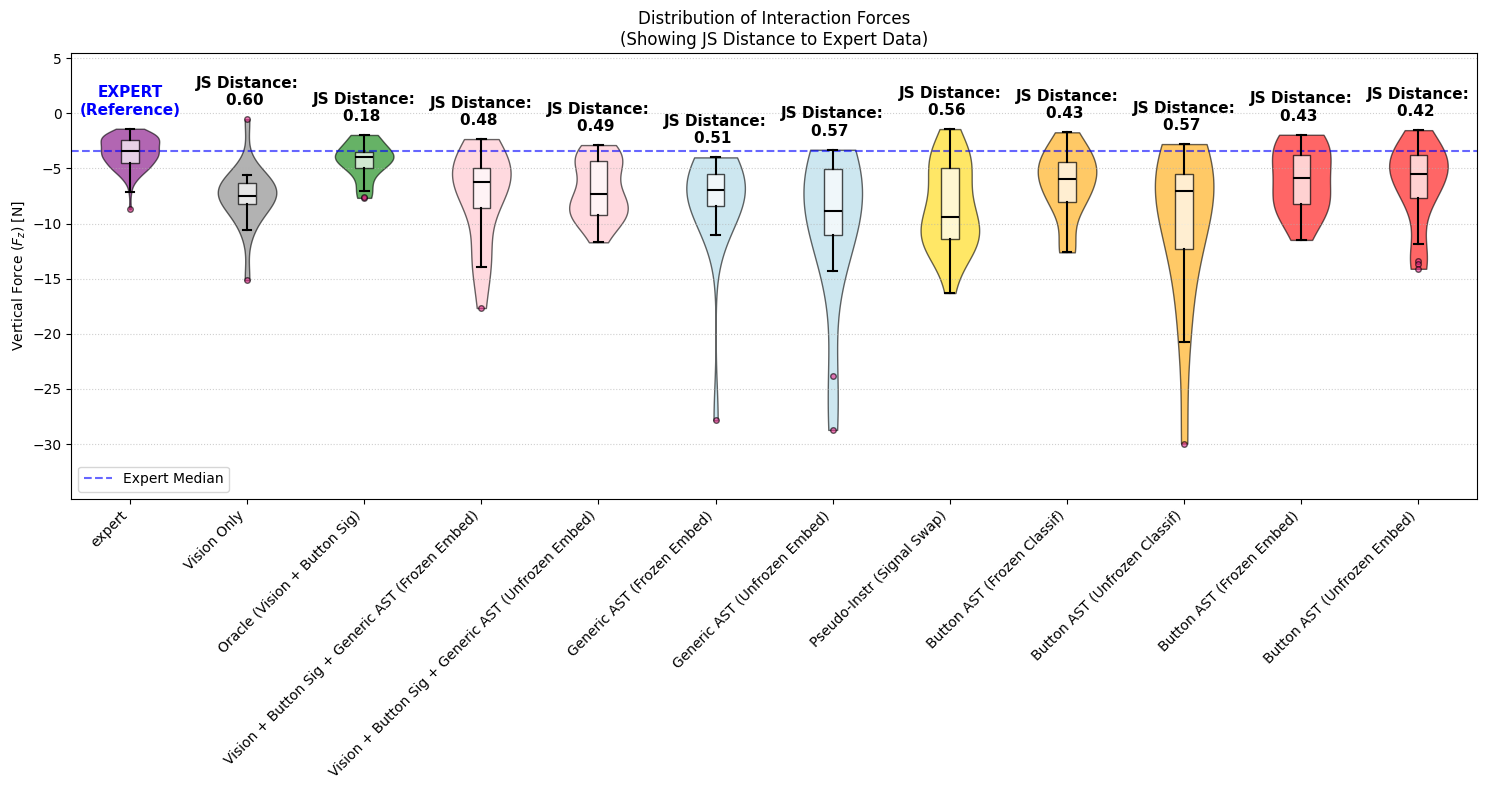

In [6]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
# Use your filtered force data
data_source = fz_peaks_filtered_sideways
labels = names

EXPERT_IDX = 0  # Assuming the first item is the Expert demonstration

# ==========================================
# 1. SETUP KERNEL DENSITY ESTIMATION (KDE)
# ==========================================
# To compute KL and JS divergence for continuous samples, we must estimate 
# their probability densities over a shared range of X values.
global_min = min([np.min(d) for d in data_source if len(d) > 0])
global_max = max([np.max(d) for d in data_source if len(d) > 0])

# Create a shared X-axis grid with 1000 points, padded by 5 Newtons on each side
x_grid = np.linspace(global_min - 5, global_max + 5, 1000)

expert_data = data_source[EXPERT_IDX]
expert_kde = stats.gaussian_kde(expert_data)
expert_pdf = expert_kde.evaluate(x_grid)

# ==========================================
# 2. CALCULATE DISTANCES TO EXPERT
# ==========================================
distances_wasserstein =[]
distances_kl = []
distances_js = []
distances_energy =[]

print("=" * 110)
print(f"{'Policy Name':<42} | {'Wasserstein':<11} | {'Energy':<11} | {'KL Diverg.':<11} | {'JS Distance':<11}")
print("-" * 110)

for i, data in enumerate(data_source):
    if len(data) < 2:
        distances_wasserstein.append(np.nan)
        distances_kl.append(np.nan)
        distances_js.append(np.nan)
        distances_energy.append(np.nan)
        print(f"{labels[i]:<42} | Not enough data")
        continue

    # 1. Wasserstein Distance (Earth Mover's Distance)
    dist_w = stats.wasserstein_distance(expert_data, data)
    
    # 2. Energy Distance
    dist_e = stats.energy_distance(expert_data, data)
    
    # --- Density Based Metrics (Require KDE) ---
    policy_kde = stats.gaussian_kde(data)
    policy_pdf = policy_kde.evaluate(x_grid)
    
    # Avoid division by zero in KL by adding a tiny epsilon
    epsilon = 1e-10
    expert_pdf_safe = expert_pdf + epsilon
    policy_pdf_safe = policy_pdf + epsilon
    
    # 3. KL Divergence: KL(Policy || Expert)
    # Measures information lost if Expert is used to approximate Policy
    dist_kl = stats.entropy(policy_pdf_safe, expert_pdf_safe)
    
    # 4. Jensen-Shannon Distance
    # Symmetrical, bounded between 0.0 and 1.0. 
    dist_js = jensenshannon(policy_pdf_safe, expert_pdf_safe)
    
    # Store
    distances_wasserstein.append(dist_w)
    distances_energy.append(dist_e)
    distances_kl.append(dist_kl)
    distances_js.append(dist_js)
    
    if i == EXPERT_IDX:
        print(f"{labels[i]:<42} | {'0.00 (REF)':<11} | {'0.00':<11} | {'0.00':<11} | {'0.00':<11}")
    else:
        print(f"{labels[i]:<42} | {dist_w:<8.2f} N | {dist_e:<8.2f}   | {dist_kl:<8.2f}    | {dist_js:<8.2f}")

print("=" * 110)

# ==========================================
# 3. PLOT WITH YOUR CHOSEN METRIC
# ==========================================
# (Choose which metric to display on the plot here)
display_distances = distances_js
metric_name = "JS Distance"
unit = "" # JS has no units. Change to "N" if using Wasserstein.

fig, ax = plt.subplots(figsize=(15, 8))

# Draw Violins & Boxplots
parts = ax.violinplot(data_source, showmeans=False, showmedians=False, showextrema=False)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.6)

bp = ax.boxplot(data_source, widths=0.15, patch_artist=True, showfliers=True, zorder=10)
for patch in bp['boxes']:
    patch.set_facecolor('white')
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
for element in['whiskers', 'caps', 'medians']:
    plt.setp(bp[element], color='black', linewidth=1.5)
plt.setp(bp['fliers'], marker='o', markerfacecolor='#e7298a', markeredgecolor='black', markersize=4, alpha=0.6)

# Add the distance text
for i, dist in enumerate(display_distances):
    y_max = np.max(data_source[i])
    
    if i == EXPERT_IDX:
        txt = "EXPERT\n(Reference)"
        font_weight = 'bold'
        color_txt = 'blue'
    else:
        txt = f"{metric_name}:\n{dist:.2f} {unit}"
        font_weight = 'bold'
        color_txt = 'black'
        
    ax.text(i + 1, y_max + 1, txt, ha='center', va='bottom', 
            fontsize=11, fontweight=font_weight, color=color_txt)

# Baselines
expert_median = np.median(data_source[EXPERT_IDX]) 
plt.axhline(y=expert_median, color='blue', linestyle='--', linewidth=1.5, alpha=0.6, label="Expert Median")

# Labels
plt.ylabel("Vertical Force ($F_z$) [N]")
plt.title(f"Distribution of Interaction Forces\n(Showing {metric_name} to Expert Data)")
ax.set_xticks(np.arange(1, len(names) + 1))
ax.set_xticklabels(names, rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='lower left')

y_global_min = min([np.min(d) for d in data_source if len(d)>0])
y_global_max = max([np.max(d) for d in data_source if len(d)>0])
ax.set_ylim(bottom=y_global_min - 5, top=y_global_max + 6) 

plt.tight_layout()
plt.show()

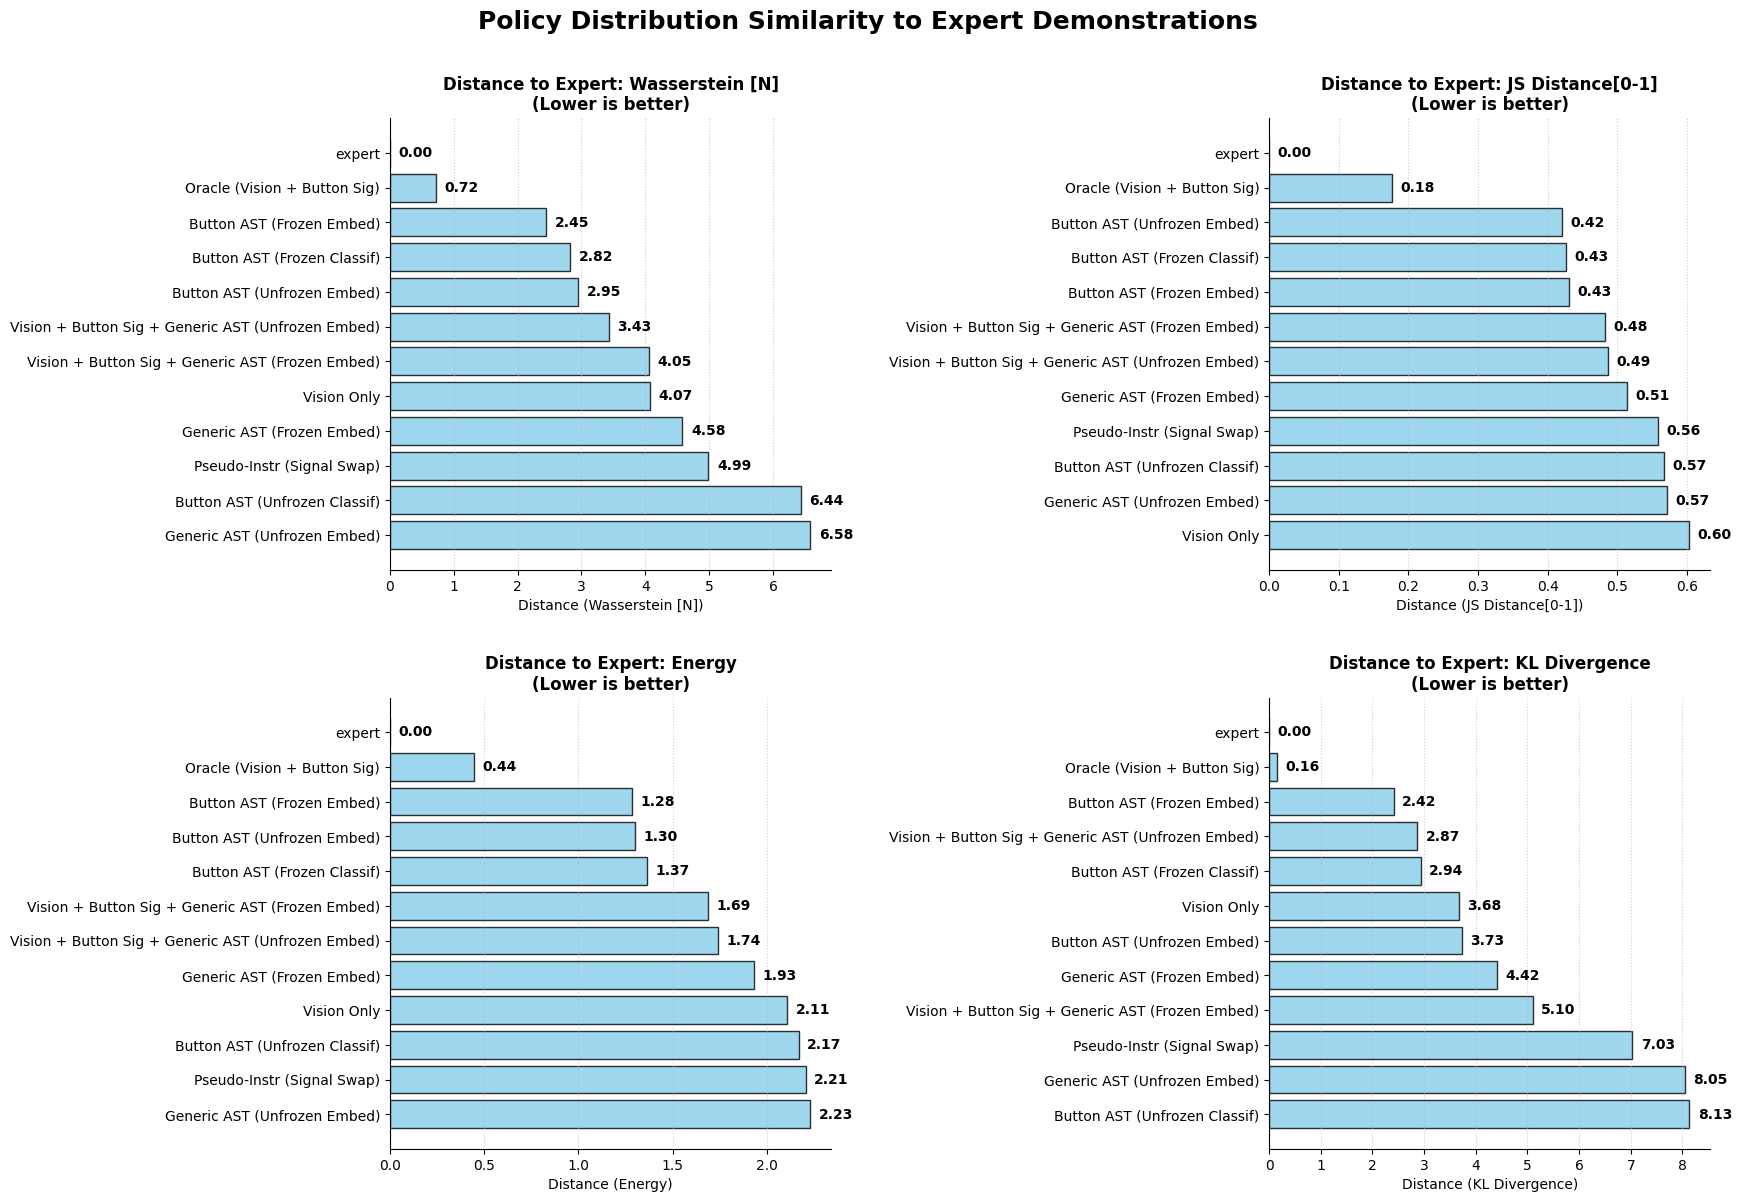

In [7]:
import numpy as np
from scipy import stats
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & CALCULATE DISTANCES (Same as before)
# ==========================================
data_source = fz_peaks_filtered_sideways
labels = names
EXPERT_IDX = 0  

# Shared grid for KDE (KL and JS)
global_min = min([np.min(d) for d in data_source if len(d) > 0])
global_max = max([np.max(d) for d in data_source if len(d) > 0])
x_grid = np.linspace(global_min - 5, global_max + 5, 1000)

expert_data = data_source[EXPERT_IDX]
expert_kde = stats.gaussian_kde(expert_data)
expert_pdf = expert_kde.evaluate(x_grid) + 1e-10

# Store distances
dist_dict = {
    "Wasserstein [N]": [],
    "JS Distance[0-1]": [],
    "Energy": [],
    "KL Divergence":[]
}

for i, data in enumerate(data_source):
    if len(data) < 2:
        for k in dist_dict: dist_dict[k].append(np.nan)
        continue

    # Wasserstein & Energy
    dist_dict["Wasserstein [N]"].append(stats.wasserstein_distance(expert_data, data))
    dist_dict["Energy"].append(stats.energy_distance(expert_data, data))
    
    # KDE based metrics
    policy_pdf = stats.gaussian_kde(data).evaluate(x_grid) + 1e-10
    dist_dict["KL Divergence"].append(stats.entropy(policy_pdf, expert_pdf))
    dist_dict["JS Distance[0-1]"].append(jensenshannon(policy_pdf, expert_pdf))

# ==========================================
# 2. PLOT HORIZONTAL BAR CHARTS (LEADERBOARDS)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (metric_name, dist_values) in enumerate(dist_dict.items()):
    ax = axes[i]
    
    # Combine labels and distances, dropping NaNs
    valid_data =[(label, dist) for label, dist in zip(labels, dist_values) if not np.isnan(dist)]
    
    # Sort by distance (Lowest = Best = Closest to Expert)
    valid_data.sort(key=lambda x: x[1])
    
    sorted_labels = [x[0] for x in valid_data]
    sorted_dists = [x[1] for x in valid_data]
    
    # Colors: Make the Expert blue, and everything else skyblue
    colors =['#1f77b4' if "Expert" in lbl or "Vision Only" in lbl and dist==0 else '#87CEEB' for lbl, dist in zip(sorted_labels, sorted_dists)]
    # (If the expert name is exactly labels[EXPERT_IDX], we can color it explicitly)
    colors =['#1f77b4' if lbl == labels[EXPERT_IDX] else '#87CEEB' for lbl in sorted_labels]

    # Create Horizontal Bar Plot
    y_pos = np.arange(len(sorted_labels))
    bars = ax.barh(y_pos, sorted_dists, color=colors, edgecolor='black', alpha=0.8)
    
    # Invert Y-axis so the best (0.0 distance) is at the top
    ax.invert_yaxis()
    
    # Labeling
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_labels, fontsize=10)
    ax.set_xlabel(f"Distance ({metric_name})")
    ax.set_title(f"Distance to Expert: {metric_name}\n(Lower is better)", fontweight='bold')
    ax.grid(axis='x', linestyle=':', alpha=0.6)
    
    # Add value annotations right next to the bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width + (max(sorted_dists) * 0.02), # slightly offset from the bar end
                bar.get_y() + bar.get_height()/2, 
                f'{width:.2f}', 
                ha='left', va='center', fontweight='bold', color='black')

    # Remove top and right spines for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=3.0)
plt.suptitle("Policy Distribution Similarity to Expert Demonstrations", fontsize=18, y=1.02, fontweight='bold')
plt.show()

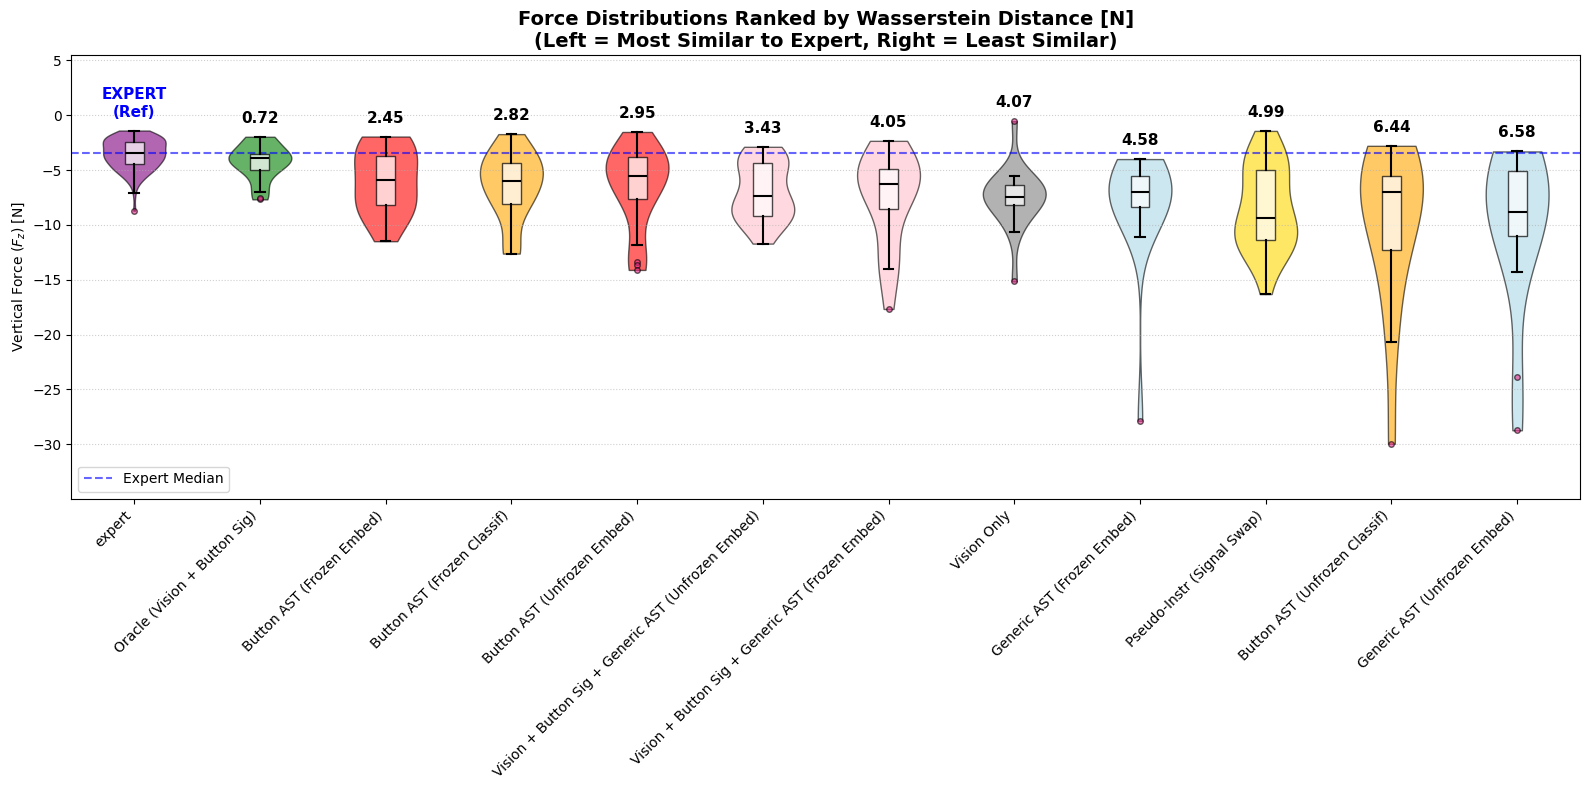

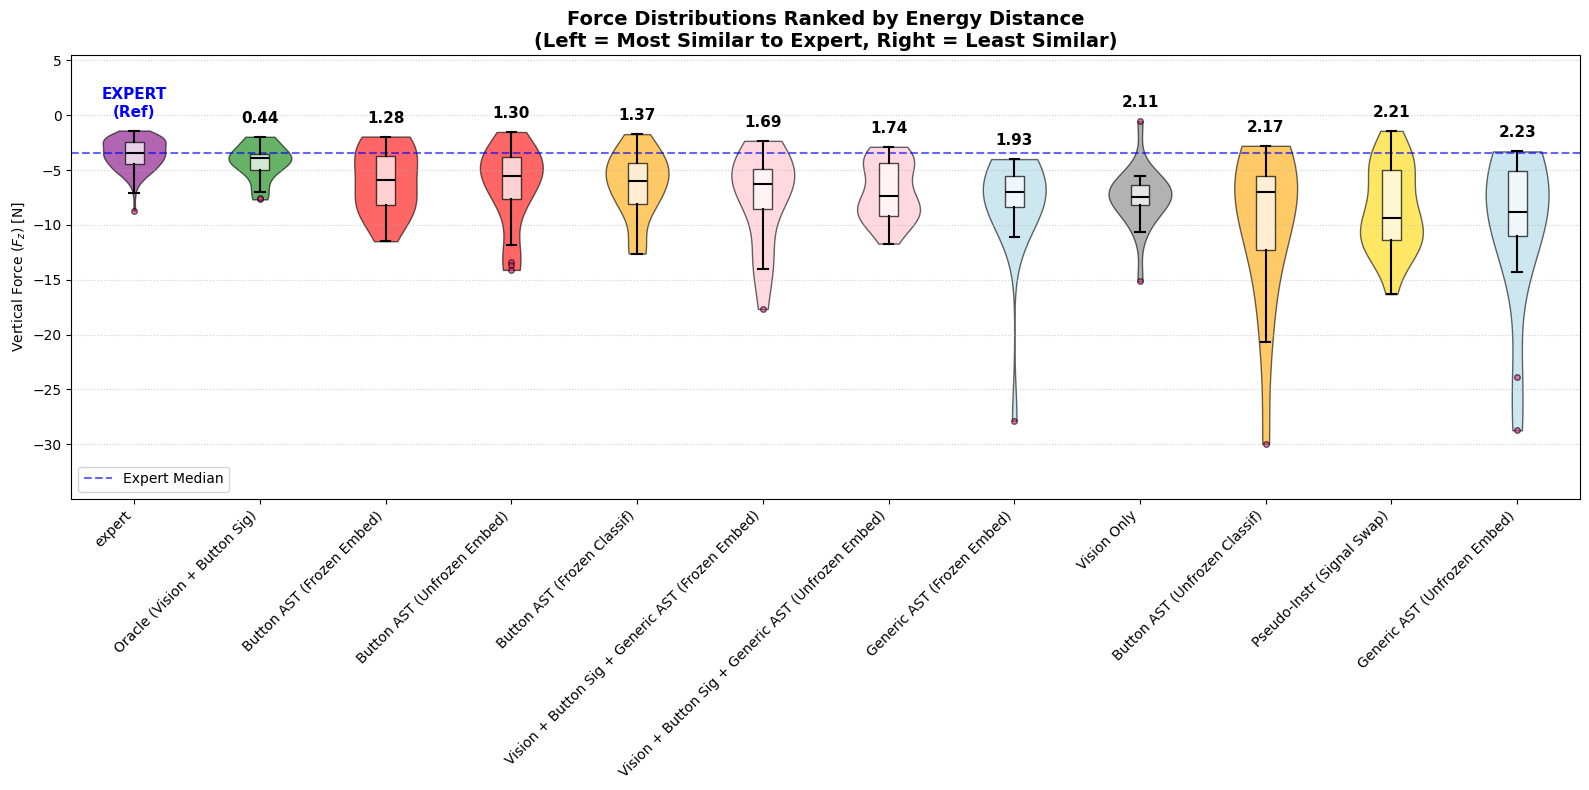

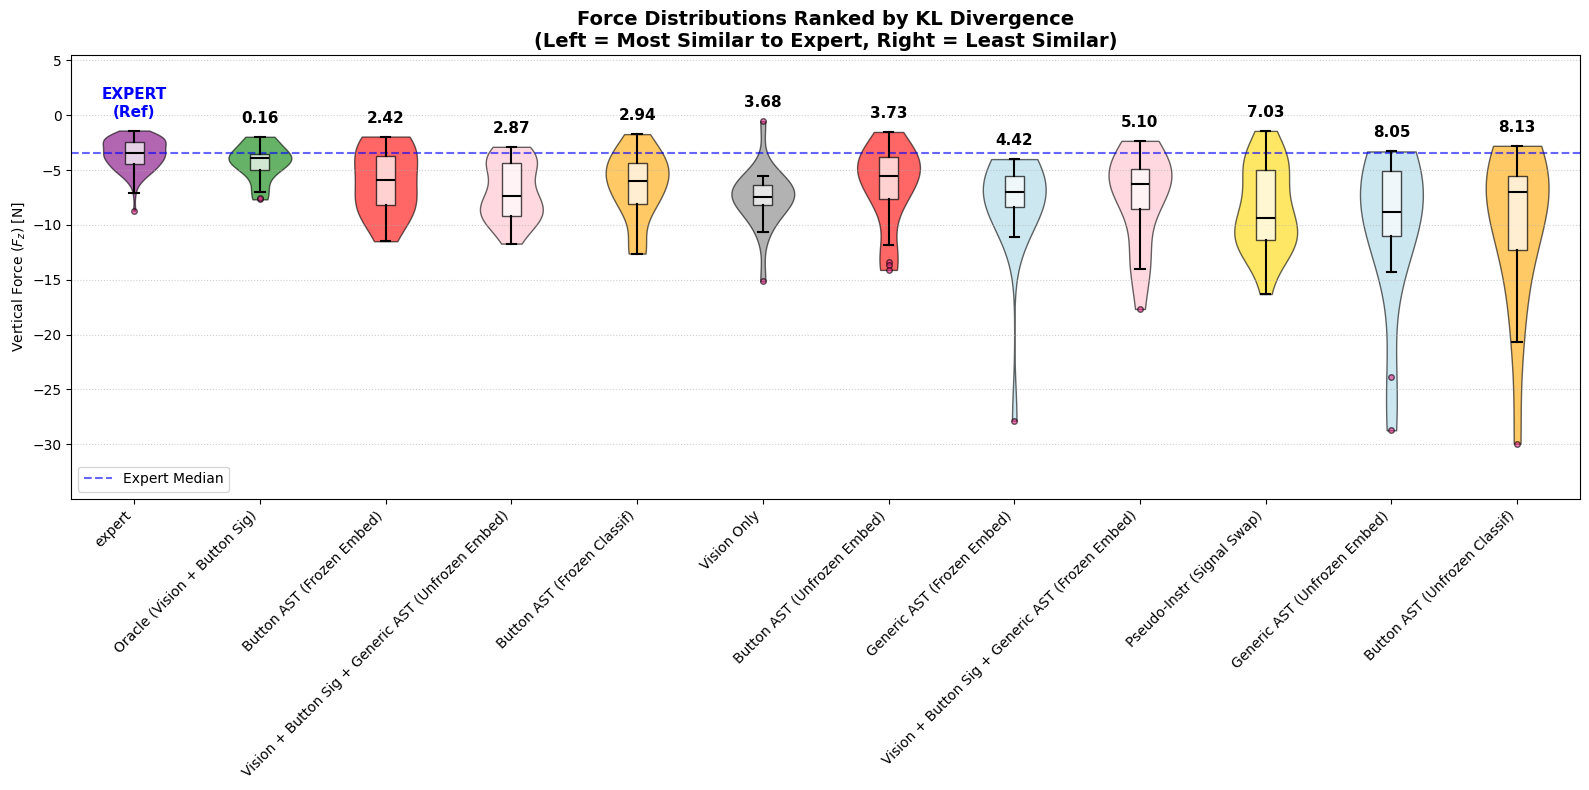

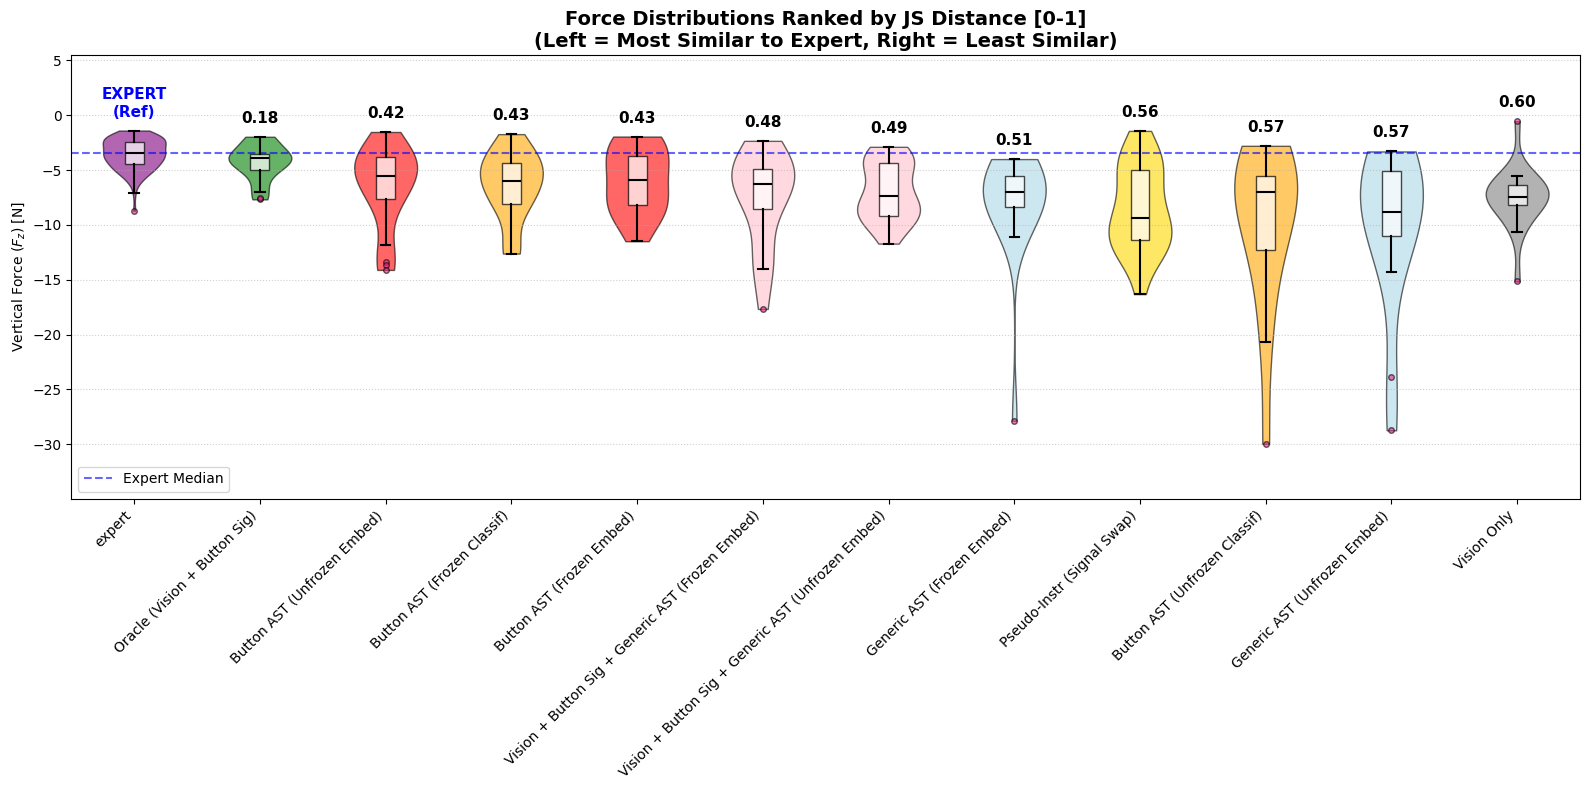

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import jensenshannon

# ==========================================
# 1. SETUP & CALCULATE ALL DISTANCES
# ==========================================
data_source = fz_peaks_filtered_sideways
labels = names
EXPERT_IDX = 0  

# Ensure we have a color for each label
# (Using your original color list, ensuring it matches the number of experiments)
base_colors =["purple"] + ['gray', 'green'] + ['pink']*2 + ['lightblue']*2 + ['gold'] + ['orange']*2 + ['red']*2
# Safely match colors to length of data
colors = base_colors[:len(labels)] 

# Shared grid for KDE (KL and JS)
global_min = min([np.min(d) for d in data_source if len(d) > 1])
global_max = max([np.max(d) for d in data_source if len(d) > 1])
x_grid = np.linspace(global_min - 5, global_max + 5, 1000)

expert_data = data_source[EXPERT_IDX]
expert_kde = stats.gaussian_kde(expert_data)
expert_pdf = expert_kde.evaluate(x_grid) + 1e-10

# Calculate all 4 metrics
distances = {
    "Wasserstein Distance [N]": [],
    "Energy Distance":[],
    "KL Divergence": [],
    "JS Distance [0-1]":[]
}

for i, data in enumerate(data_source):
    if len(data) < 2:
        for k in distances: distances[k].append(np.inf) # Put invalid data at the end
        continue

    # 1. Wasserstein & 2. Energy
    distances["Wasserstein Distance [N]"].append(stats.wasserstein_distance(expert_data, data))
    distances["Energy Distance"].append(stats.energy_distance(expert_data, data))
    
    # KDE based metrics
    policy_pdf = stats.gaussian_kde(data).evaluate(x_grid) + 1e-10
    
    # 3. KL & 4. JS
    distances["KL Divergence"].append(stats.entropy(policy_pdf, expert_pdf))
    distances["JS Distance [0-1]"].append(jensenshannon(policy_pdf, expert_pdf))

# ==========================================
# 2. GENERATE THE 4 SORTED VIOLIN PLOTS
# ==========================================

for metric_name, dist_list in distances.items():
    
    # --- Sort the data based on the current metric ---
    # Create a list of tuples: (distance, index)
    # This allows us to sort everything identically
    sort_tuples =[(dist, i) for i, dist in enumerate(dist_list)]
    sort_tuples.sort(key=lambda x: x[0]) # Sort by distance (lowest to highest)
    
    # Unpack the sorted data
    sorted_dists = [t[0] for t in sort_tuples]
    sorted_indices = [t[1] for t in sort_tuples]
    
    sorted_data =[data_source[i] for i in sorted_indices]
    sorted_labels = [labels[i] for i in sorted_indices]
    sorted_colors = [colors[i] for i in sorted_indices]

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(16, 8))

    # 1. Draw Violins
    parts = ax.violinplot(sorted_data, showmeans=False, showmedians=False, showextrema=False)
    for pc, color in zip(parts['bodies'], sorted_colors):
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.6)

    # 2. Draw Boxplots
    bp = ax.boxplot(sorted_data, widths=0.15, patch_artist=True, showfliers=True, zorder=10)
    for patch in bp['boxes']:
        patch.set_facecolor('white')
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
    for element in['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1.5)
    plt.setp(bp['fliers'], marker='o', markerfacecolor='#e7298a', markeredgecolor='black', markersize=4, alpha=0.6)

    # 3. Add Distance Annotations Above Violins
    for i, dist in enumerate(sorted_dists):
        # Handle the Expert label
        if sorted_indices[i] == EXPERT_IDX:
            txt = "EXPERT\n(Ref)"
            font_weight = 'bold'
            color_txt = 'blue'
        elif np.isinf(dist):
            txt = "N/A"
            font_weight = 'normal'
            color_txt = 'gray'
        else:
            txt = f"{dist:.2f}"
            font_weight = 'bold'
            color_txt = 'black'
            
        y_max = np.max(sorted_data[i]) if len(sorted_data[i]) > 0 else 0
        ax.text(i + 1, y_max + 1, txt, ha='center', va='bottom', 
                fontsize=11, fontweight=font_weight, color=color_txt)

    # 4. Add Expert Baseline
    expert_median = np.median(expert_data)
    plt.axhline(y=expert_median, color='blue', linestyle='--', linewidth=1.5, alpha=0.6, label="Expert Median")

    # 5. Labels and Formatting
    plt.ylabel("Vertical Force ($F_z$) [N]")
    plt.title(f"Force Distributions Ranked by {metric_name}\n(Left = Most Similar to Expert, Right = Least Similar)", fontweight='bold', fontsize=14)
    
    ax.set_xticks(np.arange(1, len(sorted_labels) + 1))
    ax.set_xticklabels(sorted_labels, rotation=45, ha='right')
    
    # Adjust Y-limits to make room for text
    y_global_min = min([np.min(d) for d in sorted_data if len(d)>0])
    y_global_max = max([np.max(d) for d in sorted_data if len(d)>0])
    ax.set_ylim(bottom=y_global_min - 5, top=y_global_max + 6)
    
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')
    plt.tight_layout()
    
    # Show this specific plot
    plt.show()

wasserstein distance

In [9]:
names

['expert',
 'Vision Only',
 'Oracle (Vision + Button Sig)',
 'Vision + Button Sig + Generic AST (Frozen Embed)',
 'Vision + Button Sig + Generic AST (Unfrozen Embed)',
 'Generic AST (Frozen Embed)',
 'Generic AST (Unfrozen Embed)',
 'Pseudo-Instr (Signal Swap)',
 'Button AST (Frozen Classif)',
 'Button AST (Unfrozen Classif)',
 'Button AST (Frozen Embed)',
 'Button AST (Unfrozen Embed)']

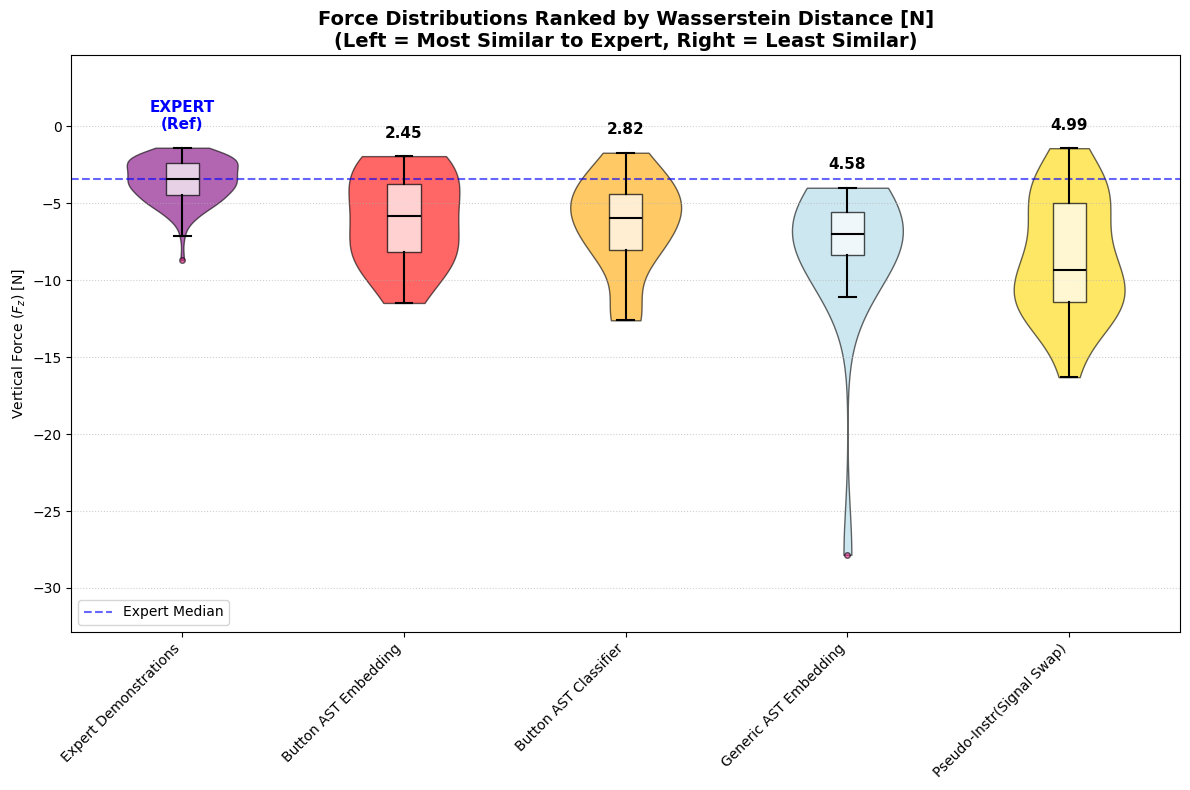

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================
# 1. SETUP & CALCULATE ALL DISTANCES
# ==========================================
data_source = fz_peaks_filtered_sideways
labels = names
EXPERT_IDX = 0  

# Ensure we have a color for each label
base_colors = ["purple"] + ['gray', 'green'] +['pink']*2 + ['lightblue']*2 + ['gold'] + ['orange']*2 + ['red']*2
colors = base_colors[:len(labels)] 

expert_data = data_source[EXPERT_IDX]

# Calculate metrics
wasserstein_distance =[] 
for i, data in enumerate(data_source):
    if len(data) == 0:
        wasserstein_distance.append(np.inf)
    else:
        wasserstein_distance.append(stats.wasserstein_distance(expert_data, data))

# ==========================================
# 2. FILTER & SORT THE DATA
# ==========================================
metric_name = "Wasserstein Distance [N]"
dist_list = wasserstein_distance

# ---> NEW: Add the exact names of any policies you want to hide here <---
HIDE_LABELS =[
    "Vision Only",
    # "Generic AST (Frozen Embed)",
    "Oracle (Vision + Button Sig)",
    "Vision + Button Sig + Generic AST (Frozen Embed)",
    "Vision + Button Sig + Generic AST (Unfrozen Embed)",
    "Generic AST (Unfrozen Embed)",
    "Button AST (Unfrozen Classif)",
    "Button AST (Unfrozen Embed)"
]

# Create a list of tuples: (distance, index), filtering out the hidden ones
sort_tuples =[]
for i, dist in enumerate(dist_list):
    if labels[i] not in HIDE_LABELS:
        sort_tuples.append((dist, i))

# Sort by distance (lowest to highest)
sort_tuples.sort(key=lambda x: x[0]) 

# Unpack the sorted AND filtered data
sorted_dists = [t[0] for t in sort_tuples]
sorted_indices = [t[1] for t in sort_tuples]

sorted_data = [data_source[i] for i in sorted_indices]
sorted_labels = [labels[i] for i in sorted_indices]
sorted_colors = [colors[i] for i in sorted_indices]

# ==========================================
# 3. PLOTTING
# ==========================================
fig, ax = plt.subplots(figsize=(12, 8))

# 1. Draw Violins
parts = ax.violinplot(sorted_data, showmeans=False, showmedians=False, showextrema=False)
for pc, color in zip(parts['bodies'], sorted_colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.6)

# 2. Draw Boxplots
bp = ax.boxplot(sorted_data, widths=0.15, patch_artist=True, showfliers=True, zorder=10)
for patch in bp['boxes']:
    patch.set_facecolor('white')
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
for element in ['whiskers', 'caps', 'medians']:
    plt.setp(bp[element], color='black', linewidth=1.5)
plt.setp(bp['fliers'], marker='o', markerfacecolor='#e7298a', markeredgecolor='black', markersize=4, alpha=0.6)

# 3. Add Distance Annotations Above Violins
for i, dist in enumerate(sorted_dists):
    # Handle the Expert label
    if sorted_indices[i] == EXPERT_IDX:
        txt = "EXPERT\n(Ref)"
        font_weight = 'bold'
        color_txt = 'blue'
    elif np.isinf(dist):
        txt = "N/A"
        font_weight = 'normal'
        color_txt = 'gray'
    else:
        txt = f"{dist:.2f}"
        font_weight = 'bold'
        color_txt = 'black'
        
    y_max = np.max(sorted_data[i]) if len(sorted_data[i]) > 0 else 0
    ax.text(i + 1, y_max + 1, txt, ha='center', va='bottom', 
            fontsize=11, fontweight=font_weight, color=color_txt)

# 4. Add Expert Baseline
expert_median = np.median(expert_data)
plt.axhline(y=expert_median, color='blue', linestyle='--', linewidth=1.5, alpha=0.6, label="Expert Median")

# 5. Labels and Formatting
plt.ylabel("Vertical Force ($F_z$) [N]")
plt.title(f"Force Distributions Ranked by {metric_name}\n(Left = Most Similar to Expert, Right = Least Similar)", fontweight='bold', fontsize=14)

ax.set_xticks(np.arange(1, len(sorted_labels) + 1))
ax.set_xticklabels(["Expert Demonstrations","Button AST Embedding","Button AST Classifier","Generic AST Embedding","Pseudo-Instr(Signal Swap)"], rotation=45, ha='right')

# Adjust Y-limits to make room for text
y_global_min = min([np.min(d) for d in sorted_data if len(d)>0])
y_global_max = max([np.max(d) for d in sorted_data if len(d)>0])
ax.set_ylim(bottom=y_global_min - 5, top=y_global_max + 6)

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='lower left')
plt.tight_layout()

# Show this specific plot
plt.show()

Label                                         | M1 | M2 | M3 | M4 | M5 | M6 | M7 | M8 | M9 | M10 | M11 | M12 | M13
----------------------------------------------------------------------------------------------------------------------------------
expert                                        | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000
Generic AST (Frozen Embed)                    | 0.6078 | 0.5608 | 0.5259 | 4.5826 | 1.1839 | 0.7333 | 4.8845 | 21.1404 | 0.2631 | 1.9315 | 0.3775 | 0.5684 | 0.6078
Pseudo-Instr (Signal Swap)                    | 0.6692 | 0.6209 | 0.6043 | 4.9901 | 1.7032 | 0.6618 | 7.8686 | 22.9018 | 0.3117 | 2.2057 | 0.4869 | 0.6687 | 0.6692
Button AST (Frozen Classif)                   | 0.4855 | 0.4623 | 0.4124 | 2.8236 | 1.1835 | 0.5082 | 3.2339 | 21.2274 | 0.1815 | 1.3664 | 0.2405 | 0.3918 | 0.4855
Button AST (Frozen Embed)                     | 0.4950 | 0.4657 | 0.4090 | 2.4508 | 1.0506 | 0.5025

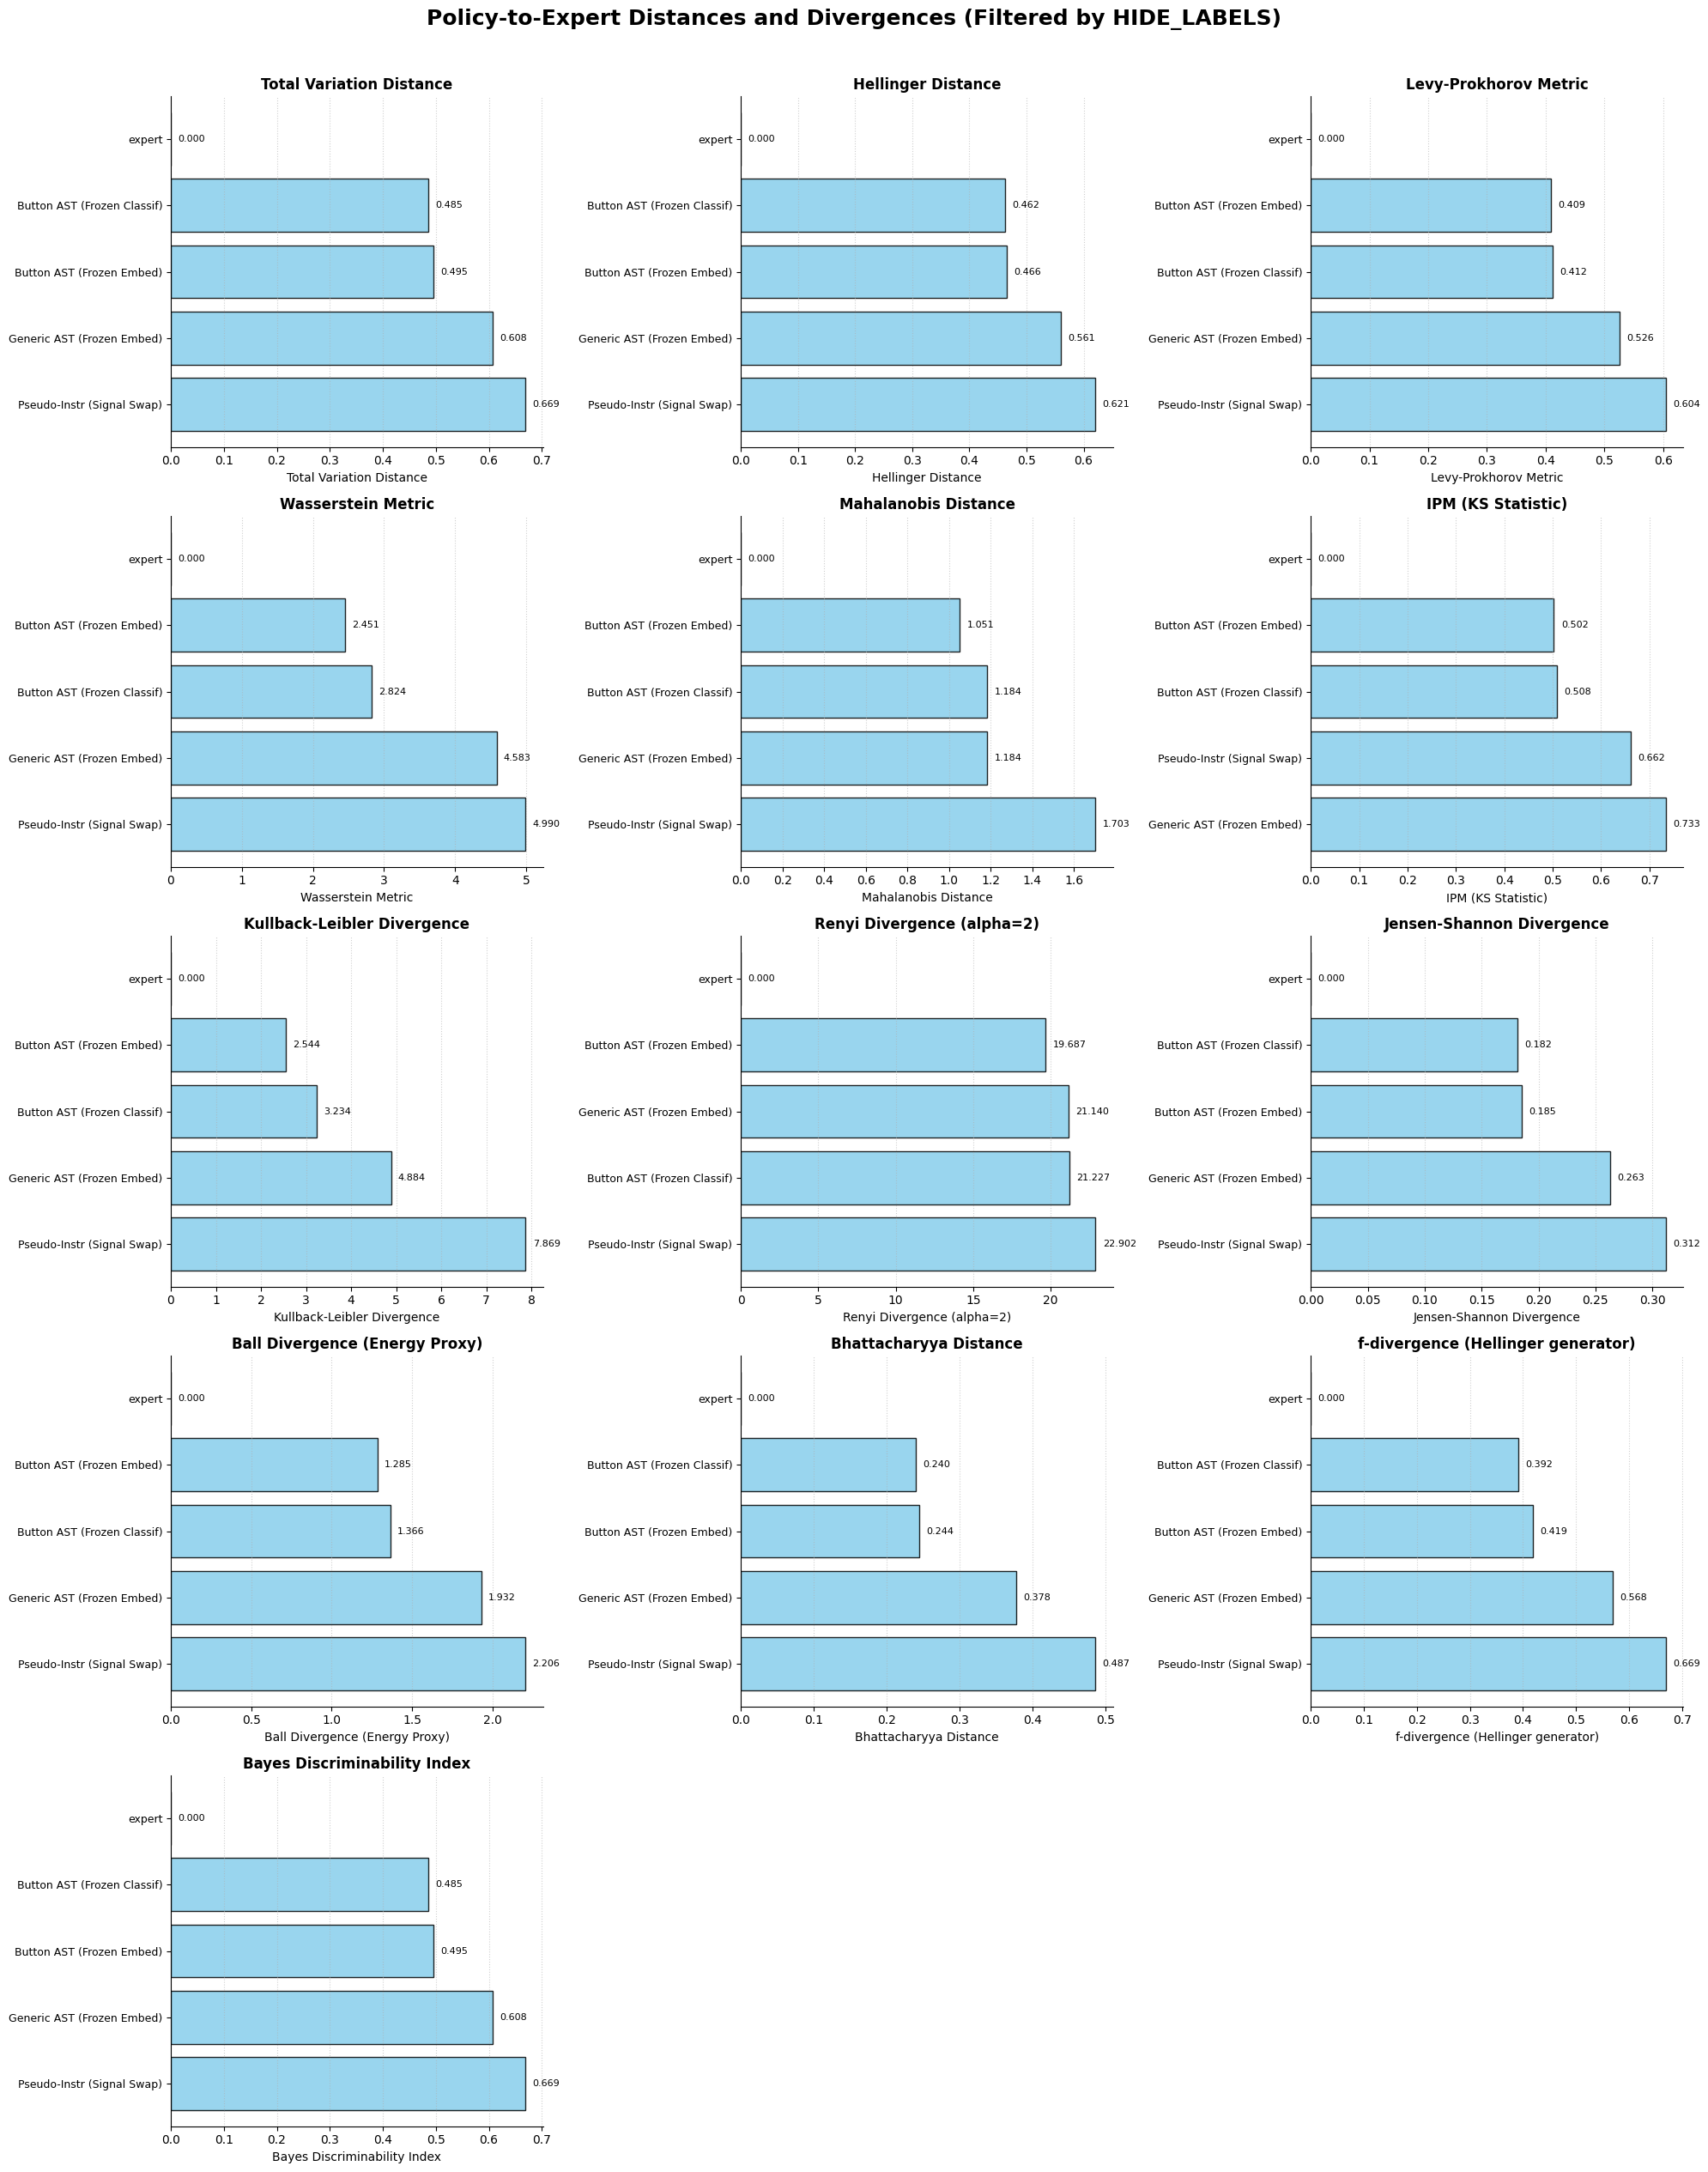

In [11]:
# Distances/divergences requested from Wikipedia-style list
# Includes practical sample-based implementations for 1D empirical force distributions.

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import jensenshannon

# ==========================================
# 1. CONFIGURATION
# ==========================================
data_source = fz_peaks_filtered_sideways
labels = names
EXPERT_IDX = 0

# Hide labels that are not needed in the final comparison
HIDE_LABELS = [
    "Vision Only",
    "Oracle (Vision + Button Sig)",
    "Vision + Button Sig + Generic AST (Frozen Embed)",
    "Vision + Button Sig + Generic AST (Unfrozen Embed)",
    "Generic AST (Unfrozen Embed)",
    "Button AST (Unfrozen Classif)",
    "Button AST (Unfrozen Embed)",
]

# Keep only wanted labels; always keep expert as reference.
visible_indices = [i for i, lbl in enumerate(labels) if (lbl not in HIDE_LABELS) or (i == EXPERT_IDX)]
visible_indices = sorted(set(visible_indices))

filtered_data = [np.asarray(data_source[i], dtype=float) for i in visible_indices]
filtered_labels = [labels[i] for i in visible_indices]

# If expert was filtered out by mistake, add it back as first element.
if EXPERT_IDX not in visible_indices:
    filtered_data = [np.asarray(data_source[EXPERT_IDX], dtype=float)] + filtered_data
    filtered_labels = [labels[EXPERT_IDX]] + filtered_labels

# Expert is now the first element in the filtered arrays.
expert_data = filtered_data[0]

# Shared support for density-based metrics
global_min = min(np.min(d) for d in filtered_data if len(d) > 1)
global_max = max(np.max(d) for d in filtered_data if len(d) > 1)
x_grid = np.linspace(global_min - 5.0, global_max + 5.0, 1200)
dx = x_grid[1] - x_grid[0]

# KDE helper
EPS = 1e-12

def kde_pdf(samples):
    if len(samples) < 2:
        return None
    pdf = stats.gaussian_kde(samples).evaluate(x_grid)
    pdf = np.maximum(pdf, EPS)
    pdf = pdf / np.trapz(pdf, x_grid)
    return pdf

expert_pdf = kde_pdf(expert_data)
expert_cdf = np.cumsum(expert_pdf) * dx

# ==========================================
# 2. METRIC IMPLEMENTATIONS
# ==========================================

def total_variation(p, q):
    return 0.5 * np.sum(np.abs(p - q)) * dx

def hellinger_distance(p, q):
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2) * dx)

def levy_prokhorov_metric(F, G, x):
    # Discrete approximation of inf eps satisfying:
    # F(x-eps)-eps <= G(x) <= F(x+eps)+eps for all x.
    eps_candidates = np.linspace(0.0, 1.0, 600)
    for eps in eps_candidates:
        x_left = np.clip(x - eps, x[0], x[-1])
        x_right = np.clip(x + eps, x[0], x[-1])
        F_left = np.interp(x_left, x, F)
        F_right = np.interp(x_right, x, F)
        lower_ok = np.all(G >= (F_left - eps))
        upper_ok = np.all(G <= (F_right + eps))
        if lower_ok and upper_ok:
            return eps
    return np.nan

def mahalanobis_1d(a, b):
    # 1D Mahalanobis between means using pooled variance.
    ma = np.mean(a)
    mb = np.mean(b)
    va = np.var(a, ddof=1) if len(a) > 1 else 0.0
    vb = np.var(b, ddof=1) if len(b) > 1 else 0.0
    pooled = 0.5 * (va + vb)
    if pooled <= EPS:
        return np.nan
    return np.abs(ma - mb) / np.sqrt(pooled)

def ipm_ks(a, b):
    # Example Integral Probability Metric: KS statistic.
    return stats.ks_2samp(a, b).statistic

def kl_divergence(p, q):
    return np.sum(p * np.log((p + EPS) / (q + EPS))) * dx

def renyi_divergence(p, q, alpha=2.0):
    if alpha == 1.0:
        return kl_divergence(p, q)
    val = np.sum((p ** alpha) * (q ** (1.0 - alpha))) * dx
    return np.log(val + EPS) / (alpha - 1.0)

def js_divergence(p, q):
    # scipy gives JS distance, so square it for divergence.
    d = jensenshannon(p, q)
    return d ** 2

def ball_divergence_proxy(a, b):
    # Practical proxy in SciPy-only workflow: energy distance.
    # (Ball divergence itself is not in scipy.)
    return stats.energy_distance(a, b)

def bhattacharyya_distance(p, q):
    bc = np.sum(np.sqrt(p * q)) * dx
    return -np.log(bc + EPS)

def f_divergence_hellinger_generator(p, q):
    # f-divergence with f(t)=(sqrt(t)-1)^2.
    ratio = p / (q + EPS)
    f_val = (np.sqrt(ratio) - 1.0) ** 2
    return np.sum(q * f_val) * dx

def bayes_discriminability_index(p, q):
    # Symmetric overlap-based discriminability: 1 - overlap coefficient.
    overlap = np.sum(np.minimum(p, q)) * dx
    return 1.0 - overlap

# ==========================================
# 3. COMPUTE ALL REQUESTED METRICS
# ==========================================
metric_dict = {
    "Total Variation Distance": [],
    "Hellinger Distance": [],
    "Levy-Prokhorov Metric": [],
    "Wasserstein Metric": [],
    "Mahalanobis Distance": [],
    "IPM (KS Statistic)": [],
    "Kullback-Leibler Divergence": [],
    "Renyi Divergence (alpha=2)": [],
    "Jensen-Shannon Divergence": [],
    "Ball Divergence (Energy Proxy)": [],
    "Bhattacharyya Distance": [],
    "f-divergence (Hellinger generator)": [],
    "Bayes Discriminability Index": [],
}

for i, data in enumerate(filtered_data):
    if len(data) < 2:
        for k in metric_dict:
            metric_dict[k].append(np.nan)
        continue

    if i == 0:
        # Expert against itself
        for k in metric_dict:
            metric_dict[k].append(0.0)
        continue

    policy_pdf = kde_pdf(data)
    policy_cdf = np.cumsum(policy_pdf) * dx

    metric_dict["Total Variation Distance"].append(total_variation(policy_pdf, expert_pdf))
    metric_dict["Hellinger Distance"].append(hellinger_distance(policy_pdf, expert_pdf))
    metric_dict["Levy-Prokhorov Metric"].append(levy_prokhorov_metric(expert_cdf, policy_cdf, x_grid))
    metric_dict["Wasserstein Metric"].append(stats.wasserstein_distance(expert_data, data))
    metric_dict["Mahalanobis Distance"].append(mahalanobis_1d(expert_data, data))
    metric_dict["IPM (KS Statistic)"].append(ipm_ks(expert_data, data))

    metric_dict["Kullback-Leibler Divergence"].append(kl_divergence(policy_pdf, expert_pdf))
    metric_dict["Renyi Divergence (alpha=2)"].append(renyi_divergence(policy_pdf, expert_pdf, alpha=2.0))
    metric_dict["Jensen-Shannon Divergence"].append(js_divergence(policy_pdf, expert_pdf))
    metric_dict["Ball Divergence (Energy Proxy)"].append(ball_divergence_proxy(expert_data, data))
    metric_dict["Bhattacharyya Distance"].append(bhattacharyya_distance(policy_pdf, expert_pdf))
    metric_dict["f-divergence (Hellinger generator)"].append(f_divergence_hellinger_generator(policy_pdf, expert_pdf))
    metric_dict["Bayes Discriminability Index"].append(bayes_discriminability_index(policy_pdf, expert_pdf))

# ==========================================
# 4. PRINT TABLE
# ==========================================
print("=" * 130)
print(f"{'Label':<45} | " + " | ".join([f"M{i+1}" for i in range(len(metric_dict))]))
print("-" * 130)
for i, lbl in enumerate(filtered_labels):
    vals = []
    for metric_name in metric_dict:
        v = metric_dict[metric_name][i]
        vals.append(f"{v:.4f}" if np.isfinite(v) else "nan")
    print(f"{lbl:<45} | " + " | ".join(vals))
print("=" * 130)

print("\nMetric Index:")
for j, name in enumerate(metric_dict.keys(), start=1):
    print(f"M{j}: {name}")

# ==========================================
# 5. LEADERBOARD PLOTS (LOWER = CLOSER TO EXPERT)
# ==========================================
n_metrics = len(metric_dict)
n_cols = 3
n_rows = int(np.ceil(n_metrics / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, (metric_name, values) in enumerate(metric_dict.items()):
    ax = axes[idx]

    valid = [(lbl, val) for lbl, val in zip(filtered_labels, values) if np.isfinite(val)]
    valid.sort(key=lambda t: t[1])

    sorted_labels = [t[0] for t in valid]
    sorted_vals = [t[1] for t in valid]
    bar_colors = ["#1f77b4" if lbl == filtered_labels[0] else "#87CEEB" for lbl in sorted_labels]

    y_pos = np.arange(len(sorted_labels))
    bars = ax.barh(y_pos, sorted_vals, color=bar_colors, edgecolor="black", alpha=0.85)
    ax.invert_yaxis()

    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_labels, fontsize=9)
    ax.set_xlabel(metric_name)
    ax.set_title(metric_name, fontweight="bold")
    ax.grid(axis="x", linestyle=":", alpha=0.6)

    offset = (max(sorted_vals) * 0.02) if len(sorted_vals) > 0 and max(sorted_vals) > 0 else 0.01
    for bar in bars:
        w = bar.get_width()
        ax.text(w + offset, bar.get_y() + bar.get_height() / 2, f"{w:.3f}", va="center", ha="left", fontsize=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused subplot slots
for j in range(n_metrics, len(axes)):
    axes[j].axis("off")

plt.suptitle("Policy-to-Expert Distances and Divergences (Filtered by HIDE_LABELS)", fontsize=18, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

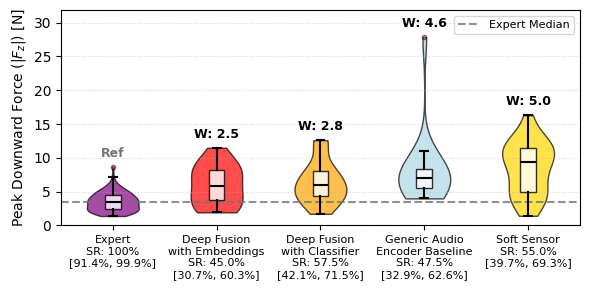

<Figure size 640x480 with 0 Axes>

In [17]:
from tkinter import font

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def remove_outliers_iqr(data, k=1.5):
    if len(data) == 0:
        return data
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return data[(data >= lower) & (data <= upper)]

# ==========================================
# 1. SETUP & CALCULATE ALL DISTANCES
# ==========================================
# Assuming `fz_peaks_filtered_sideways` and `names` are defined as before.
# We take the ABSOLUTE value so "harder press" goes UP on the Y-axis.
REMOVE_OUTLIERS = False  # Toggle this to False to keep outliers
data_source = [np.abs(d) for d in fz_peaks_filtered_sideways]

if REMOVE_OUTLIERS:
    data_source = [remove_outliers_iqr(d) for d in data_source]
labels = names
EXPERT_IDX = 0  

expert_data = data_source[EXPERT_IDX]

# Calculate metrics
wasserstein_distance =[] 
for i, data in enumerate(data_source):
    if len(data) == 0:
        wasserstein_distance.append(np.inf)
    else:
        wasserstein_distance.append(stats.wasserstein_distance(expert_data, data))

# ==========================================
# 2. FILTER & SORT THE DATA
# ==========================================
HIDE_LABELS =[
    "Vision Only",
    "Oracle (Vision + Button Sig)",
    "Vision + Button Sig + Generic AST (Frozen Embed)",
    "Vision + Button Sig + Generic AST (Unfrozen Embed)",
    "Generic AST (Unfrozen Embed)",
    "Button AST (Unfrozen Classif)",
    "Button AST (Unfrozen Embed)"
]

sort_tuples =[]
for i, dist in enumerate(wasserstein_distance):
    if labels[i] not in HIDE_LABELS:
        sort_tuples.append((dist, i))

sort_tuples.sort(key=lambda x: x[0]) 

sorted_dists = [t[0] for t in sort_tuples]
sorted_indices = [t[1] for t in sort_tuples]
sorted_data = [data_source[i] for i in sorted_indices]
sorted_labels_raw = [labels[i] for i in sorted_indices]

# Define custom short labels and Success Rates (SR) for the X-axis
short_labels_map = {
    "Expert Demonstrations": "Expert\nSR: 100%\n[91.4%, 99.9%]",
    "Button AST Embedding": "Deep Fusion\nwith Embeddings\nSR: 45.0%\n[30.7%, 60.3%]",
    "Button AST Classifier": "Deep Fusion\nwith Classifier\nSR: 57.5%\n[42.1%, 71.5%]",
    "Generic AST Embedding": "Generic Audio\nEncoder Baseline\nSR: 47.5%\n[32.9%, 62.6%]",
    "Pseudo-Instr(Signal Swap)": "Soft Sensor\nSR: 55.0%\n[39.7%, 69.3%]"
}
sorted_labels =[short_labels_map[i] for i in short_labels_map]

# Semantic Colors: Gray for Expert, Blue for Good, Red/Orange for Bad

sorted_colors = [colors[i] for i in sorted_indices]

# ==========================================
# 3. PLOTTING (Optimized for 1 Column)
# ==========================================
fig, ax = plt.subplots(figsize=(6, 3)) # Compact for 2-column paper

# 1. Draw Violins
parts = ax.violinplot(sorted_data, showmeans=False, showmedians=False, showextrema=False)
for pc, color in zip(parts['bodies'], sorted_colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 2. Draw Boxplots
bp = ax.boxplot(sorted_data, widths=0.15, patch_artist=True, showfliers=True, zorder=10)
for patch in bp['boxes']:
    patch.set_facecolor('white')
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')
for element in ['whiskers', 'caps', 'medians']:
    plt.setp(bp[element], color='black', linewidth=1.5)
plt.setp(bp['fliers'], marker='o', markerfacecolor='#e7298a', markeredgecolor='black', markersize=3, alpha=0.5)

# 3. Add Distance Annotations Above Violins
for i, dist in enumerate(sorted_dists):
    if sorted_indices[i] == EXPERT_IDX:
        txt = "Ref"
        font_weight = 'bold'
        color_txt = '#757575'
    else:
        txt = f"W: {dist:.1f}" # W for Wasserstein
        font_weight = 'bold'
        color_txt = 'black'
        
    y_max = np.max(sorted_data[i]) if len(sorted_data[i]) > 0 else 0
    # Add annotation slightly above the max point
    ax.text(i + 1, y_max + 1, txt, ha='center', va='bottom', 
            fontsize=9, fontweight=font_weight, color=color_txt)

# 4. Add Expert Baseline
expert_median = np.median(expert_data)
plt.axhline(y=expert_median, color='#757575', linestyle='--', linewidth=1.5, alpha=0.8, label="Expert Median")

# 5. Labels and Formatting
plt.ylabel("Peak Downward Force ($|F_z|$) [N]")
# Removed main title, we will rely on LaTeX caption

ax.set_xticks(np.arange(1, len(sorted_labels) + 1))
ax.set_xticklabels(sorted_labels, rotation=0, ha='center', fontsize=8)
# ax.set_xticklabels(["Expert","Button AST\nEmbedding","Button AST\nClassifier","Generic AST\nEmbedding","Pseudo-Instr\n(Signal Swap)"], ha='center',fontsize=8)

# Adjust Y-limits
y_global_min = min([np.min(d) for d in sorted_data if len(d)>0])
y_global_max = max([np.max(d) for d in sorted_data if len(d)>0])
ax.set_ylim(bottom=max(0, y_global_min - 2), top=y_global_max + 4) # 0 is absolute floor

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()

plt.show()
#save figure as pdf
plt.savefig("force_violins.pdf", dpi=300, bbox_inches='tight')

bayesian posterior successrate

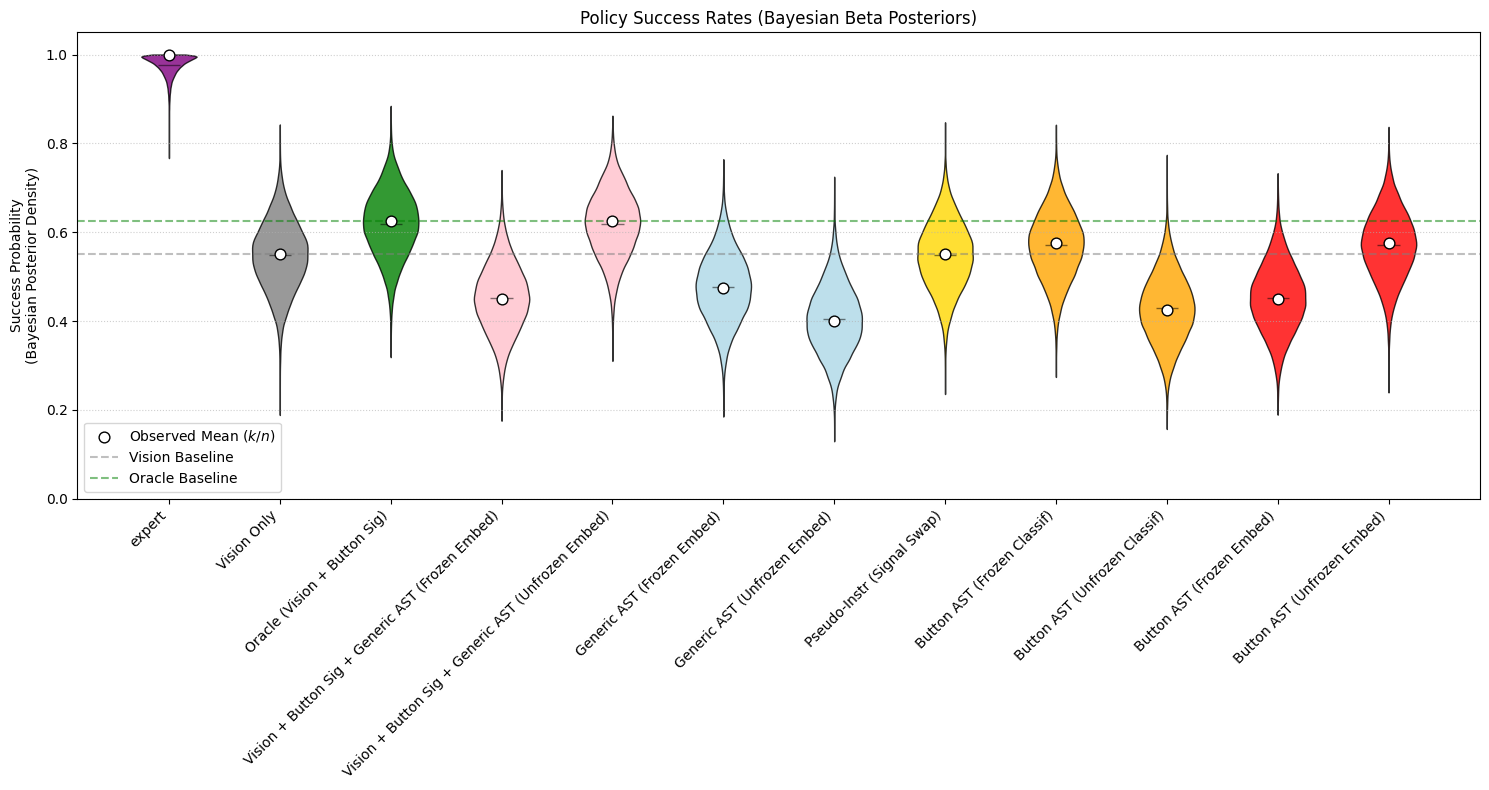

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta

# ==========================================
# 1. CONFIGURATION & DATA PREP
# ==========================================
# (Assuming 'experiments' list is already loaded from your previous code)

names = [e["name"] for e in experiments]
colors = ["purple"] +  ['gray', 'green'] + ['pink']*2 + ['lightblue']*2 + ['gold'] + ['orange']*2 + ['red']*2

# ==========================================
# 2. GENERATE BETA POSTERIORS
# ==========================================
beta_samples = []
observed_means = []

# We generate many samples to make the violin look smooth
NUM_SAMPLES = 50000 

for exp in experiments:
    cats = exp["cats"]
    
    # 1. Get counts
    n_total = sum(cats.values())
    n_success = cats.get("Success", 0) # Use "Strict" success
    n_failure = n_total - n_success
    
    # 2. Apply Uniform Prior Beta(1,1)
    # The math is simple: just add +1 to both success and failure counts
    alpha_param = n_success + 1
    beta_param  = n_failure + 1
    
    # 3. Generate samples from this distribution
    dist_samples = beta.rvs(alpha_param, beta_param, size=NUM_SAMPLES)
    beta_samples.append(dist_samples)
    
    # Save the simple calculated mean (k/n) for the white dot
    observed_means.append(n_success / n_total)

# ==========================================
# 3. PLOT TRI-STYLE VIOLINS
# ==========================================
fig, ax = plt.subplots(figsize=(15, 8))

# Create Violin Plot
# showextrema=False removes the min/max lines to make it look cleaner (like TRI)
parts = ax.violinplot(beta_samples, showmeans=False, showmedians=False, showextrema=False)

# --- STYLING ---

# 1. Color the violin bodies
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.8) # High opacity makes the shape clearer

# 2. Add the White Dot (The observed Success Rate)
# This helps people anchor the visualization to the actual number
ax.scatter(np.arange(1, len(names) + 1), observed_means, 
           color='white', edgecolor='black', s=60, zorder=10, label="Observed Mean ($k/n$)")

# 3. Add a small line for the Bayesian Mean (Expected Value)
# The mean of Beta(a,b) is a / (a+b)
for i, exp in enumerate(experiments):
    cats = exp["cats"]
    n_success = cats.get("Success", 0)
    n_total = sum(cats.values())
    
    # Bayesian Mean (with the +1 prior included)
    bayes_mean = (n_success + 1) / (n_total + 2)
    
    # Draw a small horizontal line at the Bayesian mean
    ax.hlines(bayes_mean, i+0.9, i+1.1, color='black', linewidth=1, alpha=0.5)

# ==========================================
# 4. FORMATTING
# ==========================================
plt.ylabel("Success Probability\n(Bayesian Posterior Density)")
plt.title("Policy Success Rates (Bayesian Beta Posteriors)")

# Set Y-axis to 0-1 (Probability)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# X-Axis Labels
ax.set_xticks(np.arange(1, len(names) + 1))
ax.set_xticklabels(names, rotation=45, ha='right')

# Add Baselines (Optional)
# We use the observed mean of the baselines for the dashed lines
plt.axhline(y=observed_means[1], color='gray', linestyle='--', alpha=0.5, label="Vision Baseline")
plt.axhline(y=observed_means[2], color='green', linestyle='--', alpha=0.5, label="Oracle Baseline")

plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [13]:
fz_peaks_filtered_sideways
# print the median, min and max for each group with group name for i, exp in enumerate(experiments):
for i, exp in enumerate(experiments):
    group_name = exp["name"]
    data = fz_peaks_filtered_sideways[i]
    median = np.median(data)
    average = np.mean(data)
    min_val = np.min(data)
    max_val = np.max(data)
    print(f"{group_name}: Average={average:.2f}, Median={median:.2f}, Min={min_val:.2f}, Max={max_val:.2f}")

expert: Average=-3.54, Median=-3.41, Min=-8.70, Max=-1.40
Vision Only: Average=-7.50, Median=-7.49, Min=-15.14, Max=-0.54
Oracle (Vision + Button Sig): Average=-4.23, Median=-3.93, Min=-7.67, Max=-1.96
Vision + Button Sig + Generic AST (Frozen Embed): Average=-7.59, Median=-6.23, Min=-17.66, Max=-2.34
Vision + Button Sig + Generic AST (Unfrozen Embed): Average=-6.97, Median=-7.35, Min=-11.70, Max=-2.88
Generic AST (Frozen Embed): Average=-8.12, Median=-6.98, Min=-27.85, Max=-4.00
Generic AST (Unfrozen Embed): Average=-10.12, Median=-8.86, Min=-28.72, Max=-3.31
Pseudo-Instr (Signal Swap): Average=-8.52, Median=-9.37, Min=-16.30, Max=-1.43
Button AST (Frozen Classif): Average=-6.36, Median=-5.95, Min=-12.61, Max=-1.73
Button AST (Unfrozen Classif): Average=-9.98, Median=-7.04, Min=-29.95, Max=-2.79
Button AST (Frozen Embed): Average=-5.99, Median=-5.87, Min=-11.49, Max=-1.95
Button AST (Unfrozen Embed): Average=-6.49, Median=-5.51, Min=-14.10, Max=-1.53


In [14]:
from scipy.stats import beta
import pandas as pd

# ==========================================
# CALCULATE BAYESIAN CREDIBLE INTERVALS (95%)
# ==========================================
results = []

print(f"{'Experiment Name':<45} | {'Observed':<8} | {'95% Credible Interval (Bayesian)':<25}")
print("-" * 90)

for exp in experiments:
    name = exp["name"]
    cats = exp["cats"]
    
    # 1. Get Data
    n_total = sum(cats.values())
    n_success = cats.get("Success", 0)
    observed_rate = n_success / n_total
    
    # 2. Define Beta Parameters (Uniform Prior: +1 to each)
    a = n_success + 1
    b = (n_total - n_success) + 1
    
    # 3. Calculate Percentiles (2.5% and 97.5%)
    lower_bound = beta.ppf(0.025, a, b)
    upper_bound = beta.ppf(0.975, a, b)
    median_est  = beta.ppf(0.50, a, b)
    
    # Store for plotting later if needed
    exp["bayes_lower"] = lower_bound
    exp["bayes_upper"] = upper_bound
    exp["bayes_median"] = median_est
    
    # Print
    print(f"{name[:45]:<45} | {observed_rate:.1%}   | [{lower_bound:.1%}, {upper_bound:.1%}]")

print("-" * 90)

Experiment Name                               | Observed | 95% Credible Interval (Bayesian)
------------------------------------------------------------------------------------------
expert                                        | 100.0%   | [91.4%, 99.9%]
Vision Only                                   | 55.0%   | [39.7%, 69.3%]
Oracle (Vision + Button Sig)                  | 62.5%   | [46.9%, 75.8%]
Vision + Button Sig + Generic AST (Frozen Emb | 45.0%   | [30.7%, 60.3%]
Vision + Button Sig + Generic AST (Unfrozen E | 62.5%   | [46.9%, 75.8%]
Generic AST (Frozen Embed)                    | 47.5%   | [32.9%, 62.6%]
Generic AST (Unfrozen Embed)                  | 40.0%   | [26.3%, 55.5%]
Pseudo-Instr (Signal Swap)                    | 55.0%   | [39.7%, 69.3%]
Button AST (Frozen Classif)                   | 57.5%   | [42.1%, 71.5%]
Button AST (Unfrozen Classif)                 | 42.5%   | [28.5%, 57.9%]
Button AST (Frozen Embed)                     | 45.0%   | [30.7%, 60.3%]
Button AST (U

we observe that comparing vision + button_signal + generic ast with the baseline vision+ button_signal, the successrate is lower, eventhough it is not significan (within 95% of posterior dist). Still, an additional experiment was done where we added an intermediate layer to see if this drop was caused because the generic ast embeddings are so high dimensional and maybe this overwhelmes the diffusion policy conditioning denoising. so the idea was to add an intermediate layer with a similar dimension to the resnet, vision encoders output.

=== Loading and Processing Datasets ===
Processing 'Vision + audio MIT AST embeddings extra layer frozen': 40 episodes found.
  -> Kept 17 valid episodes.
Processing 'Vision + audio MIT AST embeddings extra layer unfrozen': 40 episodes found.
  -> Kept 15 valid episodes.

=== Fz STATISTICAL METRICS (CALIBRATED) ===
------------------------------------------------------------
Metrics for: Expert demonstrations
  (Window: Button Click -> End of Episode)
  Fz Min : -8.7040
  Fz Max : 3.2607
  Fz Mean: -0.9281
  Fz Std : 1.5749
------------------------------------------------------------
------------------------------------------------------------
Metrics for: Vision Only
  (Window: Button Click -> End of Episode)
  Fz Min : -15.1442
  Fz Max : 22.3017
  Fz Mean: 1.4251
  Fz Std : 7.5512
------------------------------------------------------------
------------------------------------------------------------
Metrics for: Vision + button_signal (num_inference_steps = 10)
  (Window: Button Cl

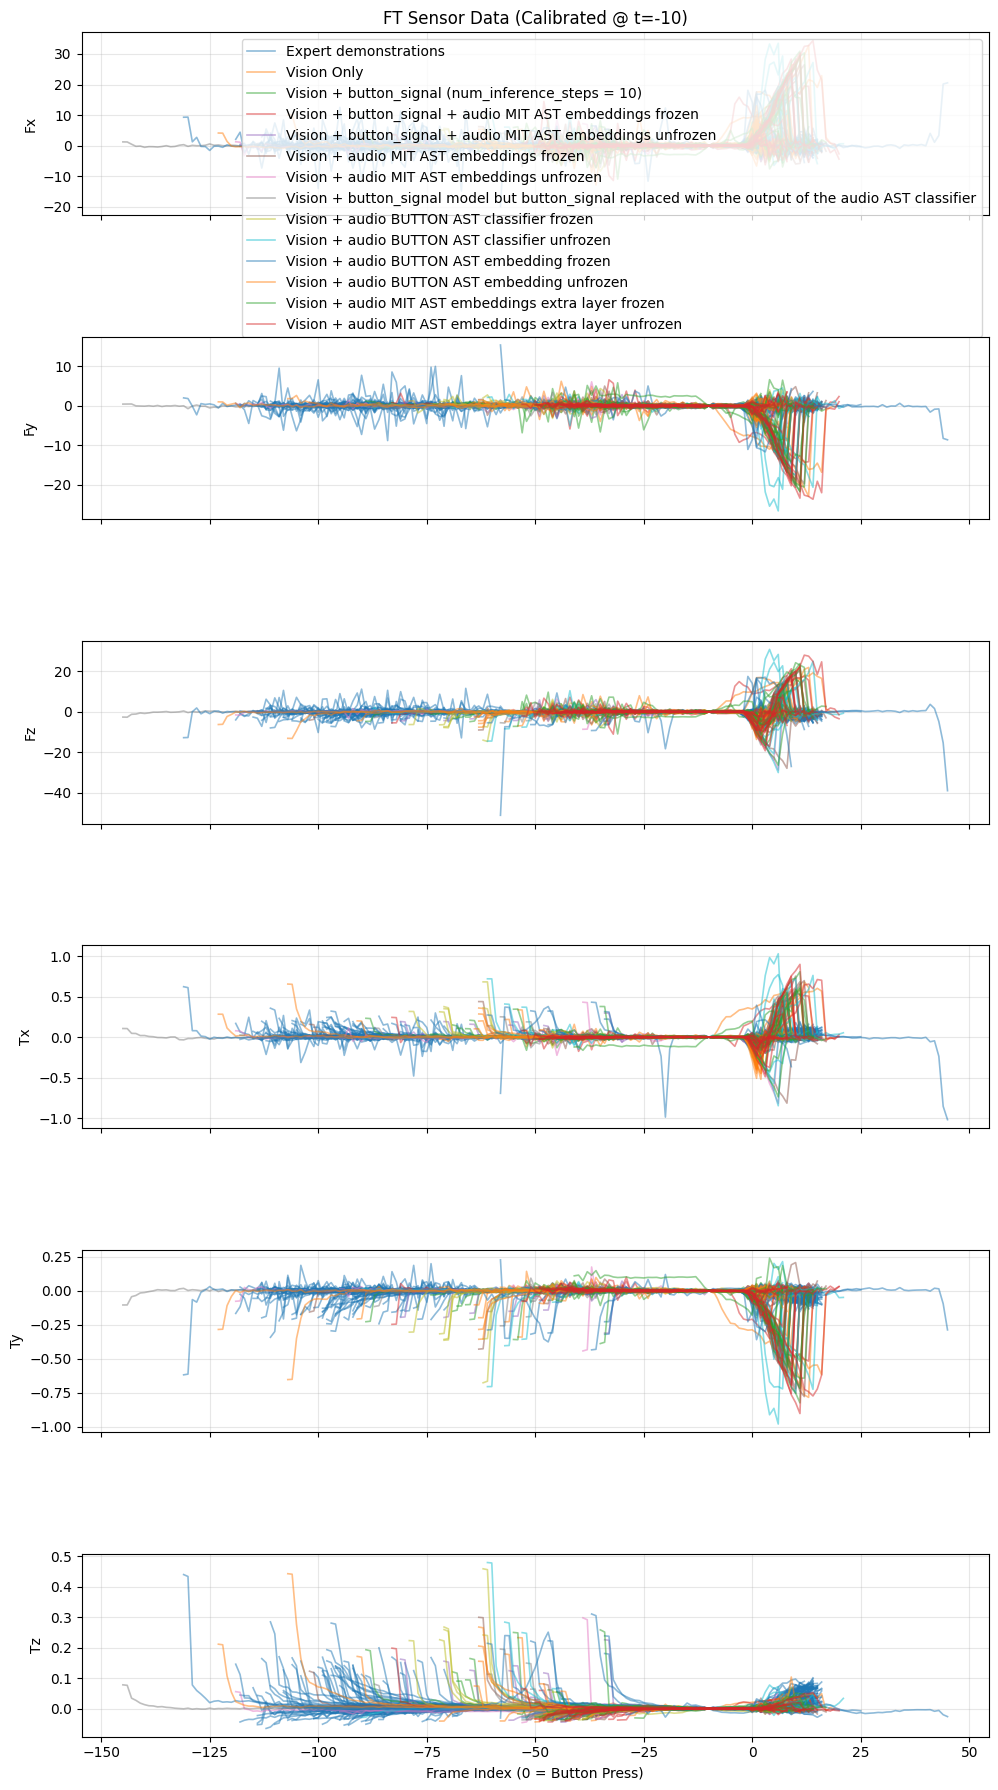

In [15]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from lerobot.datasets.lerobot_dataset import LeRobotDataset

# --- Configuration ---
# Add as many datasets as you want here. 
# Key = Label for plots/metrics, Value = Path to dataset
datasets_new = {}
datasets_new["Vision + audio MIT AST embeddings extra layer frozen"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_final_rgb_audio_mit_frozen_intermediate_fixed_button"
datasets_new["Vision + audio MIT AST embeddings extra layer unfrozen"] = "/home/rtalwar/robot-imitation-glue/datasets/eval_delta_xyz_final_rgb_audio_mit_unfrozen_intermediate_fixed_button"


# --- Main Execution Loop ---
all_processed_data = pickle.load(open("/home/rtalwar/robot-imitation-glue/datasets/all_processed_data.pkl", "rb"))


# 1. Load and Process all datasets
print("=== Loading and Processing Datasets ===")
for label, path in datasets_new.items():
    ds = LeRobotDataset(repo_id="", root=path)
    all_processed_data[label] = extract_sync_and_calibrate_episodes(ds, label)

# 2. Calculate Metrics
print("\n=== Fz STATISTICAL METRICS (CALIBRATED) ===")
for label, data in all_processed_data.items():
    print_fz_metrics(data, label)
print("\n")

# 3. Plotting
print("=== Plotting Results ===")
fig, axes = plt.subplots(6, 1, figsize=(10, 18), sharex=True)
ft_labels = ["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]

# Get default color cycle from matplotlib (Blue, Orange, Green, Red, Purple, Brown...)
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

def plot_dataset_group(axes, episode_list, color, label_prefix):
    first = True
    for ep in episode_list:
        t = ep["time"]
        ft = ep["ft"] # shape (T, 6)
        
        for dim in range(6):
            lbl = label_prefix if (first and dim == 0) else None
            axes[dim].plot(t, ft[:, dim], color=color, alpha=0.5, linewidth=1.2, label=lbl)
        first = False

# Loop over processed data and plot each
for i, (label, data) in enumerate(all_processed_data.items()):
    # Pick a color from the cycle (modulo to wrap around if >10 datasets)
    color = color_cycle[i % len(color_cycle)]
    plot_dataset_group(axes, data, color, label)

# Formatting
for i in range(6):
    axes[i].set_ylabel(ft_labels[i])
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(loc="upper right")
        axes[i].set_title("FT Sensor Data (Calibrated @ t=-10)")

axes[-1].set_xlabel("Frame Index (0 = Button Press)")
plt.tight_layout()
plt.show()

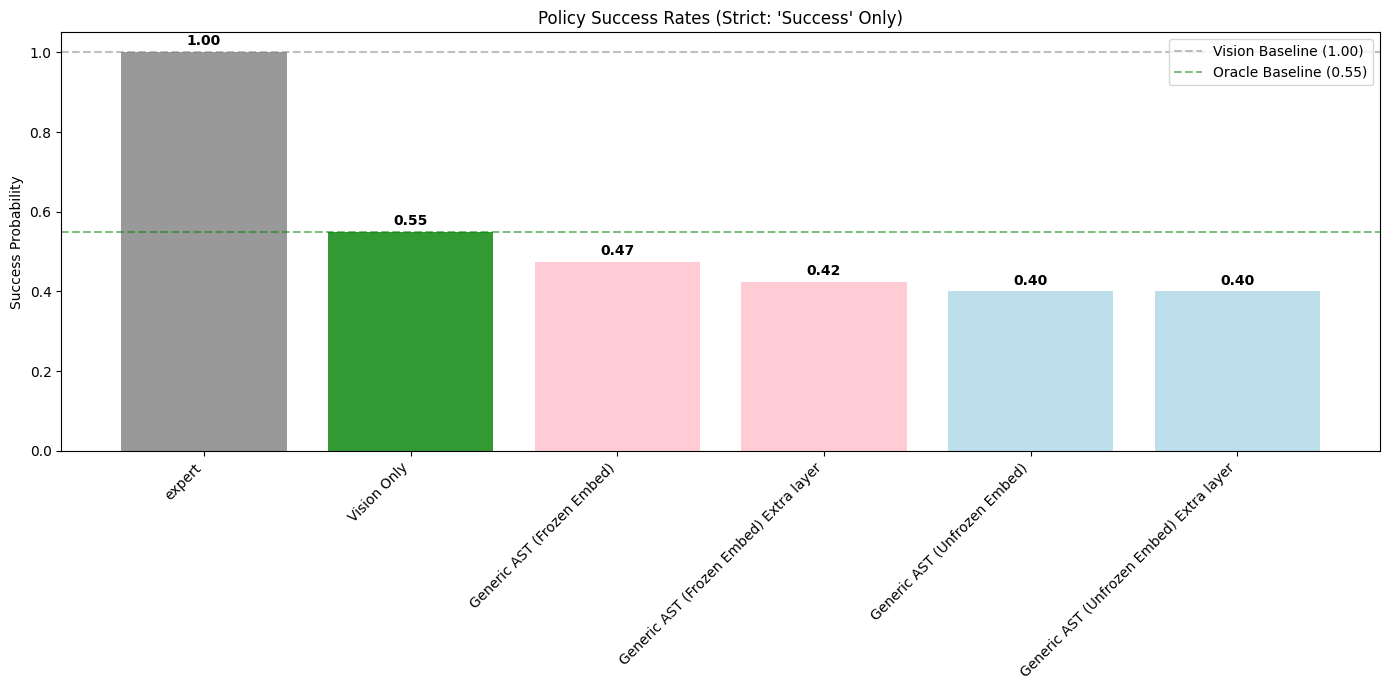

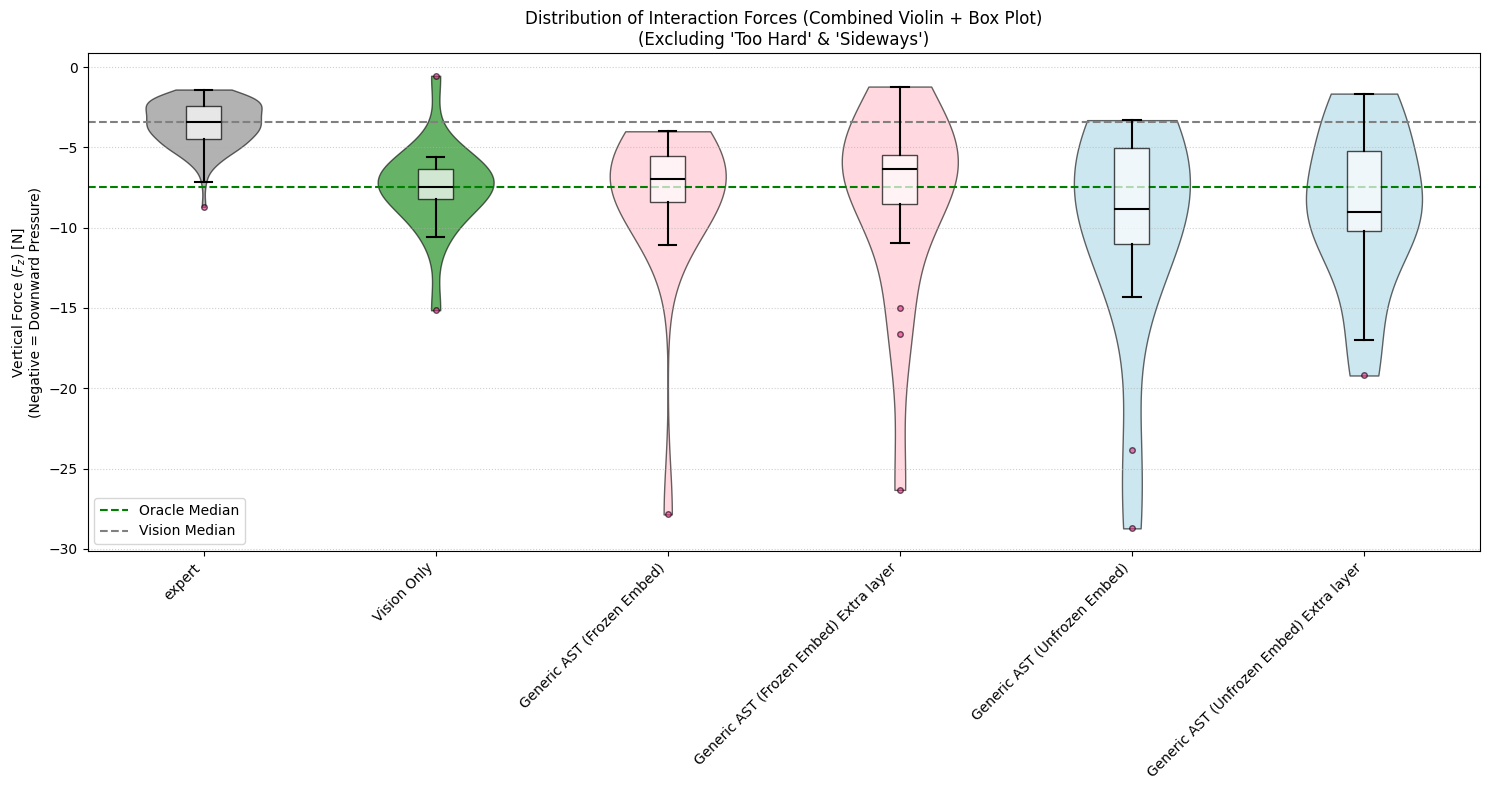

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import math

# ==========================================
# 1. DATA CONFIGURATION
# ==========================================
experiments = [
    # --- Baselines ---
    {
        "name": "expert",
        "cats": {"Hover": 0, "Too Hard": 0, "Success": 40},
        "too_hard_index":[],
        "sideways":[]
    },
    {
        "name": "Vision Only",
        "cats": {"Hover": 16, "Too Hard": 0, "Success": 22,"Sideways": 2},
        "too_hard_index":[],
        "sideways":[20,37]
    },
    # --- Generic AST (MIT) ---
    {
        "name": "Generic AST (Frozen Embed)",
        "cats": {"Hover": 21, "Too Hard": 0, "Success": 19},
        "too_hard_index":[],
        "sideways":[]
    },
    {
        "name": "Generic AST (Frozen Embed) Extra layer",
        "cats": {"Hover": 22, "Too Hard": 0, "Success": 17,"Sideways": 1},
        "too_hard_index":[],
        "sideways":[20]
    },
    {
        "name": "Generic AST (Unfrozen Embed)",
        "cats": {"Hover": 24, "Too Hard": 0, "Success": 16},
        "too_hard_index":[],
        "sideways":[]
    },
    {
        "name": "Generic AST (Unfrozen Embed) Extra layer",
        "cats": {"Hover": 24, "Too Hard": 0, "Success": 16},
        "too_hard_index":[],
        "sideways":[]
    },
]

# ==========================================
# 1b. CALCULATE METRICS DYNAMICALLY
# ==========================================
for exp in experiments:
    cats = exp["cats"]
    n = sum(cats.values())
    n_success = cats.get("Success", 0)
    n_hard = cats.get("Too Hard", 0)
    
    # Strict Metrics
    p_strict = n_success / n
    
    exp["p_strict"] = p_strict
    exp["total_n"] = n

names = [e["name"] for e in experiments]
colors = ['gray', 'green'] + ['pink']*2 + ['lightblue']*2 + ['gold'] + ['orange']*2 + ['red']*2

# ==========================================
# 2a. STRICT SUCCESS RATE BAR CHART
# ==========================================
success_rates = [e["p_strict"] for e in experiments]

plt.figure(figsize=(14, 7))
bars = plt.bar(names, success_rates, capsize=5, color=colors, alpha=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

base_vision = experiments[0]["p_strict"]
base_oracle = experiments[1]["p_strict"]

plt.axhline(y=base_vision, color='gray', linestyle='--', alpha=0.5, label=f"Vision Baseline ({base_vision:.2f})")
plt.axhline(y=base_oracle, color='green', linestyle='--', alpha=0.5, label=f"Oracle Baseline ({base_oracle:.2f})")

plt.ylabel("Success Probability")
plt.title("Policy Success Rates (Strict: 'Success' Only)")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 3. PREPARE FORCE DATA (ALL + FILTERED)
# ==========================================
experiment_names = [experiment["name"] for experiment in experiments]
name = list(all_processed_data.keys())
name = [name[i] for i in [0,1,5,-2,6,-1]]
# name.remove("vision + button_signal (num_inference_steps = 40)")
mapping = dict(zip(experiment_names,name))
# 1. Get Raw Data
raw_data_list = [all_processed_data[mapping[n]] for n in names]

# 2. Extract Raw Metrics (Arrays per episode)
fz_values_all_episodes = [get_fz_metrics(d) for d in raw_data_list]

# 3. Get Episode IDs
experiment_episodes = []
for experiment_runs in raw_data_list:
    episode_indices = []
    for run in experiment_runs:
        episode_indices.append(run["episode_id"])
    experiment_episodes.append(episode_indices)

# 4. Helper to extract peaks (Minimum Fz)
def extract_peak_impacts(experiment_runs):
    peaks = []
    for run in experiment_runs:
        if run is not None and len(run) > 0:
            peaks.append(np.min(run)) 
    return peaks

# 5. DATA SET A: ALL DATA
fz_peaks_all = [extract_peak_impacts(runs) for runs in fz_values_all_episodes]

# 6. DATA SET B: FILTERED DATA (No "Too Hard")
fz_peaks_filtered = []
fz_peaks_filtered_sideways = []
for i, exp_name in enumerate(names):
    bad_indices = experiments[i].get("too_hard_index", [])
    bad_indices_sideways = experiments[i].get("sideways", [])
    current_force_runs = fz_values_all_episodes[i]
    current_ids = experiment_episodes[i]
    
    clean_runs = []
    clean_runs_sideways = []
    for force_run, ep_id in zip(current_force_runs, current_ids):
        if ep_id not in bad_indices:
            clean_runs.append(force_run)
            if ep_id not in bad_indices_sideways:
                clean_runs_sideways.append(force_run)

        else:
            print(f"episode {ep_id} is being removed from experiment {exp_name}")
    fz_peaks_filtered.append(extract_peak_impacts(clean_runs))
    fz_peaks_filtered_sideways.append(extract_peak_impacts(clean_runs_sideways))


# ==========================================
# 5.2. VIOLIN PLOT + BOX PLOT OVERLAY
# ==========================================
fig, ax = plt.subplots(figsize=(15, 8))

# 1. DRAW VIOLINS (Background)
# We turn off medians/extrema here because the boxplot will handle those details
parts = ax.violinplot(fz_peaks_filtered_sideways, 
                      showmeans=False, 
                      showmedians=False, 
                      showextrema=False)

# Style the violin bodies
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.6) # Slightly more transparent to let boxplot pop

# 2. DRAW BOXPLOTS (Foreground)
# widths=0.15 makes it narrow enough to fit inside the violin
# zorder=10 ensures it draws ON TOP of the violin
bp = ax.boxplot(fz_peaks_filtered_sideways, 
                widths=0.15, 
                patch_artist=True, 
                showfliers=True, # Show outliers as dots
                zorder=10)

# Style the Boxplots (White interior helps them stand out against the colored violin)
for patch in bp['boxes']:
    patch.set_facecolor('white')
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')

# Style the Whiskers/Caps/Medians
for element in ['whiskers', 'caps', 'medians']:
    plt.setp(bp[element], color='black', linewidth=1.5)

# Style the Outliers (Fliers)
plt.setp(bp['fliers'], marker='o', markerfacecolor='#e7298a', 
         markeredgecolor='black', markersize=4, alpha=0.6)

# 3. REFERENCE LINES
# (Based on FILTERED data)
oracle_median_filt = np.median(fz_peaks_filtered_sideways[1])
vision_median_filt = np.median(fz_peaks_filtered_sideways[0])
plt.axhline(y=oracle_median_filt, color='green', linestyle='--', linewidth=1.5, label="Oracle Median")
plt.axhline(y=vision_median_filt, color='gray', linestyle='--', linewidth=1.5, label="Vision Median")

# 4. LABELS & FORMATTING
plt.ylabel("Vertical Force ($F_z$) [N]\n(Negative = Downward Pressure)")
plt.title("Distribution of Interaction Forces (Combined Violin + Box Plot)\n(Excluding 'Too Hard' & 'Sideways')")
ax.set_xticks(np.arange(1, len(names) + 1))
ax.set_xticklabels(names, rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='lower left')

# Optional: Limit Y-axis if you still want that cutoff
# ax.set_ylim(bottom=-50, top=5)

plt.tight_layout()
plt.show()

we can observe from the successrates that this intermediate layer has barely any effect, for the forces I can still do the same statistical analysis I have done before.

In [17]:
fz_peaks_filtered_sideways
# print the median, min and max for each group with group name for i, exp in enumerate(experiments):
for i, exp in enumerate(experiments):
    group_name = exp["name"]
    data = fz_peaks_filtered_sideways[i]
    median = np.median(data)
    average = np.mean(data)
    min_val = np.min(data)
    max_val = np.max(data)
    print(f"{group_name}: Average={average:.2f}, Median={median:.2f}, Min={min_val:.2f}, Max={max_val:.2f}")

expert: Average=-3.54, Median=-3.41, Min=-8.70, Max=-1.40
Vision Only: Average=-7.50, Median=-7.49, Min=-15.14, Max=-0.54
Generic AST (Frozen Embed): Average=-8.12, Median=-6.98, Min=-27.85, Max=-4.00
Generic AST (Frozen Embed) Extra layer: Average=-8.34, Median=-6.33, Min=-26.32, Max=-1.22
Generic AST (Unfrozen Embed): Average=-10.12, Median=-8.86, Min=-28.72, Max=-3.31
Generic AST (Unfrozen Embed) Extra layer: Average=-8.59, Median=-9.01, Min=-19.20, Max=-1.65


In [19]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
# Use your filtered force data
data_source = fz_peaks_filtered_sideways
labels = names

EXPERT_IDX = 0  # Assuming the first item is the Expert demonstration

# ==========================================
# 1. CALCULATE DISTANCES TO EXPERT
# ==========================================
expert_data = data_source[EXPERT_IDX]
distances =[]

print("-" * 60)
print(f"{'Policy Name':<45} | {'Distance to Expert (Wasserstein) [N]':<15}")
print("-" * 60)

for i, data in enumerate(data_source):
    if i == EXPERT_IDX:
        dist = 0.0
    else:
        # Wasserstein distance handles empirical continuous samples perfectly
        dist = stats.wasserstein_distance(expert_data, data)
        
    distances.append(dist)
    print(f"{labels[i]:<45} | {dist:.3f} N")

print("-" * 60)

------------------------------------------------------------
Policy Name                                   | Distance to Expert (Wasserstein) [N]
------------------------------------------------------------
expert                                        | 0.000 N
Vision Only                                   | 4.073 N
Generic AST (Frozen Embed)                    | 4.583 N
Generic AST (Frozen Embed) Extra layer        | 4.854 N
Generic AST (Unfrozen Embed)                  | 6.583 N
Generic AST (Unfrozen Embed) Extra layer      | 5.054 N
------------------------------------------------------------
